# Smartphone Usage and Addiction Analysis
## Setup and Data Loading

* Importing libraries 
* Loading the raw dataset 
* Doing a quick initial inspection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_csv('Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')

display(df_raw.head())

print(f"Dataset Shape: {df_raw.shape}")

print("Column Names:")
print(df_raw.columns.tolist())

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


Dataset Shape: (7500, 16)
Column Names:
['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addiction_level', 'addicted_label']


## Cleaning and Data Quality

Check data quality, inspect ranges, standardize simple text formatting, and create the `df_clean` dataframe. Gender is inspected here, but all observed gender categories are retained so that the project does not lose rows before testing whether gender is useful for prediction.

In [2]:
print(f"Shape before cleaning: {df_raw.shape}")

# Keep df_raw as the original loaded file and use a working copy for checks/standardization.
df_working = df_raw.copy()
df_working.columns = df_working.columns.str.strip()

# Check data types
print("\n--- Data Types ---")
df_working.info()

# Check missing values
print("\n--- Missing Values ---")
print(df_working.isnull().sum())

# Check duplicates
print("\n--- Duplicate Checks ---")
print(f"Duplicate rows: {df_working.duplicated().sum()}")
print(f"Duplicate transaction_ids: {df_working['transaction_id'].duplicated().sum()}")
print(f"Duplicate user_ids: {df_working['user_id'].duplicated().sum()}")

# Check unique values in categorical columns.
categorical_cols = ['gender', 'stress_level', 'academic_work_impact', 'addiction_level']
print("\n--- Categorical Unique Values ---")
for col in categorical_cols:
    if col in df_working.columns:
        if df_working[col].dtype == 'object':
            df_working[col] = df_working[col].str.strip()
        print(f"{col}: {df_working[col].unique()}")

# Check basic numeric ranges
print("\n--- Numeric Ranges ---")
display(df_working.describe())

Shape before cleaning: (7500, 16)

--- Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact    

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


### Column-Level Validity Checks

Before feature engineering or modeling, validate whether each source column follows its expected value domain. These checks are different from the later cross-field time-budget checks: a value can be valid inside its own column while still creating contradictions when combined with other columns.


In [3]:
validation_results = []

def add_validation_result(column, rule, invalid_mask, example_limit=5):
    invalid_count = int(invalid_mask.sum())
    examples = df_working.loc[invalid_mask, column].head(example_limit).tolist() if column in df_working.columns else []
    validation_results.append({
        'column': column,
        'rule': rule,
        'invalid_count': invalid_count,
        'invalid_percent': invalid_count / len(df_working) * 100,
        'examples': examples
    })

required_columns = [
    'transaction_id',
    'user_id',
    'age',
    'gender',
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time',
    'stress_level',
    'academic_work_impact',
    'addiction_level',
    'addicted_label'
]

missing_required_columns = sorted(set(required_columns) - set(df_working.columns))
unexpected_columns = sorted(set(df_working.columns) - set(required_columns))

print('Missing required columns:')
print(missing_required_columns if missing_required_columns else 'None')

print('\nUnexpected columns:')
print(unexpected_columns if unexpected_columns else 'None')

id_pattern_rules = {
    'transaction_id': r'^TXN\d{5}$',
    'user_id': r'^U\d{5}$'
}

for col, pattern in id_pattern_rules.items():
    add_validation_result(
        col,
        f'non-missing, unique, and matches pattern {pattern}',
        df_working[col].isna() | df_working[col].duplicated(keep=False) | ~df_working[col].astype(str).str.match(pattern)
    )

numeric_bounds = {
    'age': (0, 120),
    'daily_screen_time_hours': (0, 24),
    'social_media_hours': (0, 24),
    'gaming_hours': (0, 24),
    'work_study_hours': (0, 24),
    'sleep_hours': (0, 24),
    'notifications_per_day': (0, None),
    'app_opens_per_day': (0, None),
    'weekend_screen_time': (0, 48)
}

for col, (lower, upper) in numeric_bounds.items():
    numeric_values = pd.to_numeric(df_working[col], errors='coerce')
    invalid_mask = numeric_values.isna()
    if lower is not None:
        invalid_mask = invalid_mask | (numeric_values < lower)
    if upper is not None:
        invalid_mask = invalid_mask | (numeric_values > upper)
    upper_label = upper if upper is not None else 'no fixed upper bound'
    add_validation_result(col, f'numeric and within [{lower}, {upper_label}]', invalid_mask)

integer_count_columns = ['notifications_per_day', 'app_opens_per_day']
for col in integer_count_columns:
    numeric_values = pd.to_numeric(df_working[col], errors='coerce')
    add_validation_result(
        col,
        'whole-number count',
        numeric_values.isna() | (numeric_values % 1 != 0)
    )

categorical_allowed_values = {
    'gender': {'Female', 'Male', 'Other'},
    'stress_level': {'Low', 'Medium', 'High'},
    'academic_work_impact': {'No', 'Yes'},
    'addiction_level': {'Mild', 'Moderate', 'Severe'},
    'addicted_label': {0, 1}
}

for col, allowed_values in categorical_allowed_values.items():
    if col == 'addiction_level':
        invalid_mask = df_working[col].notna() & ~df_working[col].isin(allowed_values)
        rule = f'allowed values {sorted(allowed_values)} or missing'
    else:
        invalid_mask = df_working[col].isna() | ~df_working[col].isin(allowed_values)
        rule = f'allowed values {sorted(allowed_values)}'
    add_validation_result(col, rule, invalid_mask)

column_validity_df = pd.DataFrame(validation_results)
display(column_validity_df.round({'invalid_percent': 2}))

invalid_column_rules = column_validity_df[column_validity_df['invalid_count'] > 0]

if invalid_column_rules.empty:
    print('All checked source columns pass the column-level validity rules.')
else:
    print('Column-level validity issues found:')
    display(invalid_column_rules.round({'invalid_percent': 2}))

print('\nObserved age range:')
print(f"{df_working['age'].min()} to {df_working['age'].max()}")


Missing required columns:
None

Unexpected columns:
None


,column,rule,invalid_count,invalid_percent,examples
0,transaction_id,"non-missing, unique, and matches pattern ^TXN\...",0,0.0,[]
1,user_id,"non-missing, unique, and matches pattern ^U\d{5}$",0,0.0,[]
2,age,"numeric and within [0, 120]",0,0.0,[]
3,daily_screen_time_hours,"numeric and within [0, 24]",0,0.0,[]
4,social_media_hours,"numeric and within [0, 24]",0,0.0,[]
5,gaming_hours,"numeric and within [0, 24]",0,0.0,[]
6,work_study_hours,"numeric and within [0, 24]",0,0.0,[]
7,sleep_hours,"numeric and within [0, 24]",0,0.0,[]
8,notifications_per_day,"numeric and within [0, no fixed upper bound]",0,0.0,[]
9,app_opens_per_day,"numeric and within [0, no fixed upper bound]",0,0.0,[]


All checked source columns pass the column-level validity rules.

Observed age range:
18 to 35


In [4]:
# Standardize gender labels while retaining all observed categories.
df_clean = df_working.copy()

gender_mapping = {
    'male': 'Male', 'Male': 'Male', 'M': 'Male',
    'female': 'Female', 'Female': 'Female', 'F': 'Female',
    'other': 'Other', 'Other': 'Other'
}

df_clean['gender'] = df_clean['gender'].replace(gender_mapping)

expected_gender_categories = ['Female', 'Male', 'Other']
unexpected_gender_mask = ~df_clean['gender'].isin(expected_gender_categories)
unexpected_gender_count = unexpected_gender_mask.sum()

print('Gender counts after standardization:')
display(df_clean['gender'].value_counts(dropna=False).rename('count').to_frame())

print(f"Unexpected or unclear gender values: {unexpected_gender_count}")
print('No gender rows are removed at this stage. Gender will be tested for relationship with the target and then excluded from modeling if it has weak predictive value.')
print(f"\nFinal df_clean shape: {df_clean.shape}")

Gender counts after standardization:


,count
gender,
Male,2553
Other,2486
Female,2461


Unexpected or unclear gender values: 0
No gender rows are removed at this stage. Gender will be tested for relationship with the target and then excluded from modeling if it has weak predictive value.

Final df_clean shape: (7500, 16)


### Person 1 Handoff to Person 2

1. Rows and columns after cleaning: 7,500 rows and 16 columns.
2. Missing values still exist in `addiction_level`: 819 missing values. No other columns have missing values.
3. Duplicate rows: 0. Duplicate `transaction_id`: 0. Duplicate `user_id`: 0.
4. Column-level validity checks passed for required schema, ID patterns, numeric plausibility bounds, integer count fields, allowed categorical values, and binary target values.
5. Final unique values in `gender`: `Male`, `Female`, and `Other`.
6. No rows were removed for gender. The `Other` category is retained because it is an observed category, not a missing value to impute.
7. Gender will be tested against `addicted_label` before modeling. If it shows weak association, it will be excluded from the predictive feature set so the model focuses on behavioral usage variables.
8. `df_clean` is ready for Person 2 to continue preprocessing and feature preparation.


## 2. Preprocessing and Feature Preparation - Person 2

This section starts from `df_clean`, handles the remaining missing values, prepares useful engineered features for validation, and creates `df_prepared`, `X_unencoded`, `X`, and `y` for the next phases.

Important modeling rule: `transaction_id`, `user_id`, `addicted_label`, `addiction_level`, `addiction_level_display`, and the original text `gender` column are excluded from the feature matrix. `addiction_level` is excluded because it is closely related to the target and may leak target information. Categorical encoding and numeric imputation for the predictive model are handled later inside sklearn pipelines so those steps are fit only on training folds.


In [5]:
# Start from the cleaned dataframe created by Person 1
df_prepared = df_clean.copy()

numeric_columns = [
    'age',
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time',
    'addicted_label'
]

categorical_columns = [
    'gender',
    'stress_level',
    'academic_work_impact',
    'addiction_level'
]

identifier_columns = ['transaction_id', 'user_id']

print('Missing values before preprocessing:')
display(df_prepared.isna().sum().to_frame('missing_count'))

# Do not impute the target. If target values are missing, remove those rows.
target_missing = df_prepared['addicted_label'].isna().sum()
if target_missing > 0:
    df_prepared = df_prepared.dropna(subset=['addicted_label']).copy()

# Numeric columns use median imputation if missing values are present.
numeric_imputation_values = {}
for col in numeric_columns:
    if col != 'addicted_label' and df_prepared[col].isna().sum() > 0:
        median_value = df_prepared[col].median()
        df_prepared[col] = df_prepared[col].fillna(median_value)
        numeric_imputation_values[col] = median_value

# Keep addiction_level missing in the source column, but create a display-only label for EDA.
# This avoids implying that missing values are a real addiction severity category.
df_prepared['addiction_level_display'] = df_prepared['addiction_level'].fillna('Not recorded')

print('\nNumeric columns:')
print(numeric_columns)

print('\nCategorical columns:')
print(categorical_columns)

print('\nNumeric imputation values used:')
print(numeric_imputation_values if numeric_imputation_values else 'No numeric imputation needed')

print('\nCategorical display handling used:')
print("Missing addiction_level values are shown as 'Not recorded' for EDA only; addiction_level is not used for modeling.")

print('\nMissing values after preprocessing:')
display(df_prepared.isna().sum().to_frame('missing_count'))

print('\nGender categories retained for diagnostic EDA:')
display(df_prepared['gender'].value_counts(dropna=False).rename('count').to_frame())

print('\nAddiction level display counts:')
display(df_prepared['addiction_level_display'].value_counts(dropna=False).rename('count').to_frame())

Missing values before preprocessing:


,missing_count
transaction_id,0
user_id,0
age,0
gender,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0



Numeric columns:
['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'addicted_label']

Categorical columns:
['gender', 'stress_level', 'academic_work_impact', 'addiction_level']

Numeric imputation values used:
No numeric imputation needed

Categorical display handling used:
Missing addiction_level values are shown as 'Not recorded' for EDA only; addiction_level is not used for modeling.

Missing values after preprocessing:


,missing_count
transaction_id,0
user_id,0
age,0
gender,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0



Gender categories retained for diagnostic EDA:


,count
gender,
Male,2553
Other,2486
Female,2461



Addiction level display counts:


,count
addiction_level_display,
Moderate,2874
Severe,2434
Mild,1373
Not recorded,819


### Gender Relationship Check Before Modeling Exclusion

Before dropping `gender` from the modeling feature set, test whether it has a meaningful relationship with `addicted_label`. Because gender is categorical, use target-rate comparison, a chi-square test, Cramer's V, and a normalized visualization instead of relying only on a numeric correlation.

Gender vs addicted_label - counts


addicted_label,0,1
gender,,
Female,733,1728
Male,709,1844
Other,750,1736


Gender vs addicted_label - row percentages


addicted_label,0,1
gender,,
Female,29.78,70.22
Male,27.77,72.23
Other,30.17,69.83


Chi-square p-value: 0.1319
Cramer's V: 0.0232


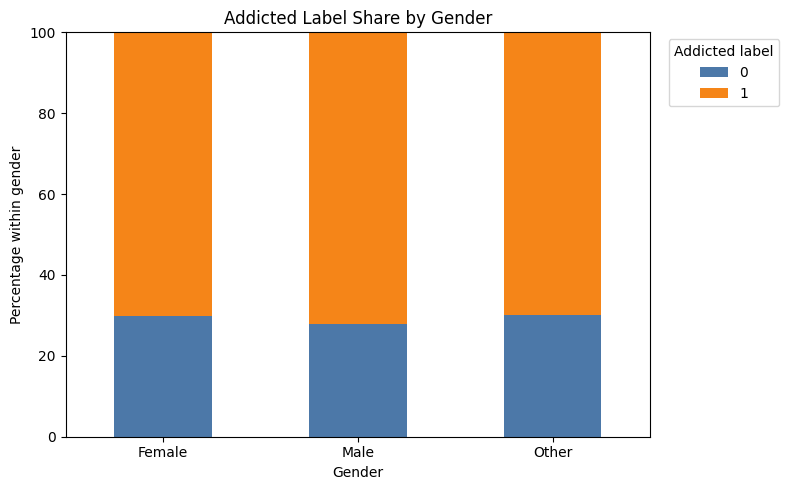

In [6]:
from scipy.stats import chi2_contingency

# Counts and row percentages show whether target rates differ by gender category.
gender_target_counts = pd.crosstab(df_prepared['gender'], df_prepared['addicted_label'])
gender_target_percentages = (
    pd.crosstab(df_prepared['gender'], df_prepared['addicted_label'], normalize='index')
    .mul(100)
    .round(2)
)

chi2, gender_chi2_p_value, gender_chi2_dof, gender_expected = chi2_contingency(gender_target_counts)
n = gender_target_counts.to_numpy().sum()
rows, cols = gender_target_counts.shape
gender_cramers_v = np.sqrt((chi2 / n) / min(rows - 1, cols - 1))

print('Gender vs addicted_label - counts')
display(gender_target_counts)

print('Gender vs addicted_label - row percentages')
display(gender_target_percentages)

print(f"Chi-square p-value: {gender_chi2_p_value:.4f}")
print(f"Cramer's V: {gender_cramers_v:.4f}")

# Normalized visualization: each gender sums to 100%, so the comparison is not distorted by group size.
gender_target_percentages.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    color=['#4C78A8', '#F58518']
)
plt.title('Addicted Label Share by Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage within gender')
plt.legend(title='Addicted label', labels=['0', '1'], bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

### Gender Diagnostic Interpretation

The gender target rates are very close across categories, and the association size is very small. This supports excluding `gender` from the predictive feature matrix instead of imputing `Other` into `Male` or `Female`, or removing one-third of the dataset. Gender remains available for descriptive checks, but the model will focus on behavioral usage variables.

### Addiction Level Target-Proxy Check

`addiction_level` is useful for descriptive context, but it must be checked carefully before modeling. If its categories map directly to `addicted_label`, then it is not an independent predictor; it is an answer-key proxy. Missing addiction levels are shown as `Not recorded` for EDA only rather than imputed as a real severity category.

Addiction level display vs addicted_label - counts


addicted_label,0,1,All
addiction_level_display,,,
Mild,1373,0,1373
Moderate,0,2874,2874
Not recorded,819,0,819
Severe,0,2434,2434
All,2192,5308,7500


Addiction level display vs addicted_label - row percentages


addicted_label,0,1
addiction_level_display,,
Mild,100.0,0.0
Moderate,0.0,100.0
Not recorded,100.0,0.0
Severe,0.0,100.0


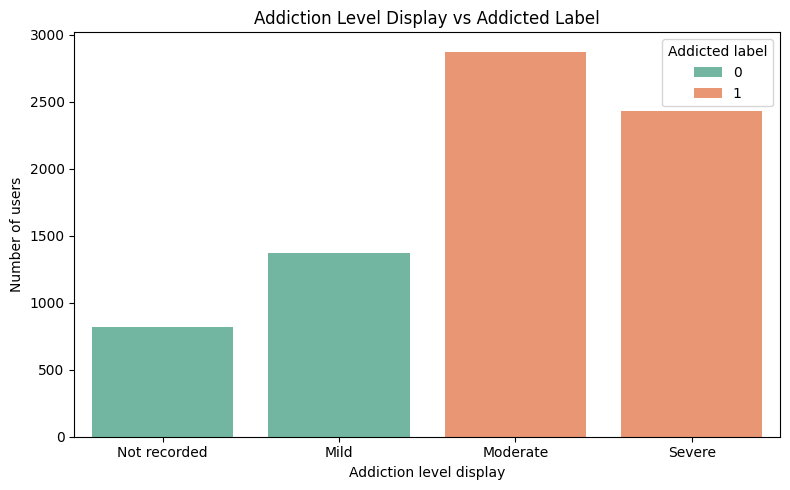

In [7]:
addiction_level_target_counts = pd.crosstab(
    df_prepared['addiction_level_display'],
    df_prepared['addicted_label'],
    margins=True
)

addiction_level_target_percentages = (
    pd.crosstab(
        df_prepared['addiction_level_display'],
        df_prepared['addicted_label'],
        normalize='index'
    )
    .mul(100)
    .round(2)
)

print('Addiction level display vs addicted_label - counts')
display(addiction_level_target_counts)

print('Addiction level display vs addicted_label - row percentages')
display(addiction_level_target_percentages)

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_prepared,
    x='addiction_level_display',
    hue='addicted_label',
    order=['Not recorded', 'Mild', 'Moderate', 'Severe'],
    palette='Set2'
)
plt.title('Addiction Level Display vs Addicted Label')
plt.xlabel('Addiction level display')
plt.ylabel('Number of users')
plt.legend(title='Addicted label')
plt.tight_layout()
plt.show()

### Addiction Level Diagnostic Interpretation

`addiction_level` behaves as a deterministic target proxy in this dataset: `Not recorded` and `Mild` align with `addicted_label = 0`, while `Moderate` and `Severe` align with `addicted_label = 1`. Therefore, `addiction_level` and its display version are excluded from predictive modeling to avoid leakage. Rows with missing `addiction_level` are kept because their behavioral features and `addicted_label` remain valid.

### Feature Preparation

The original cleaned columns are kept in `df_prepared` for EDA. New features are added to support sanity checks and empirical feature validation. Ratio features keep invalid zero-denominator cases as missing rather than silently converting them to `0`; in this dataset the guard is not triggered because the minimum daily screen time is above zero.

Gender was checked against the target before modeling and showed weak association. Therefore `gender` is retained for descriptive EDA only and excluded from the model feature matrix. `addiction_level` is also excluded because it behaves as a deterministic target proxy.


In [8]:
# Simple engineered and diagnostic features
df_prepared['usage_component_total_hours'] = (
    df_prepared['social_media_hours']
    + df_prepared['gaming_hours']
    + df_prepared['work_study_hours']
)

screen_time_zero_mask = df_prepared['daily_screen_time_hours'] == 0
screen_time_nonzero = df_prepared['daily_screen_time_hours'].replace(0, np.nan)

zero_screen_with_activity = (
    screen_time_zero_mask
    & (
        (df_prepared['notifications_per_day'] > 0)
        | (df_prepared['app_opens_per_day'] > 0)
    )
).sum()

df_prepared['notifications_per_screen_hour'] = (
    df_prepared['notifications_per_day'] / screen_time_nonzero
).replace([np.inf, -np.inf], np.nan)

df_prepared['app_opens_per_screen_hour'] = (
    df_prepared['app_opens_per_day'] / screen_time_nonzero
).replace([np.inf, -np.inf], np.nan)

df_prepared['sleep_below_7_hours'] = (df_prepared['sleep_hours'] < 7).astype(int)
df_prepared['sleep_displacement_ratio'] = df_prepared['daily_screen_time_hours'] / df_prepared['sleep_hours']
df_prepared['weekend_binge_factor'] = df_prepared['weekend_screen_time'] - df_prepared['daily_screen_time_hours']
df_prepared['multitasking_index'] = df_prepared['usage_component_total_hours'] / screen_time_nonzero

print(f'Rows with zero daily screen time: {screen_time_zero_mask.sum()}')
print(f'Rows with zero screen time but notifications/app opens: {zero_screen_with_activity}')

excluded_modeling_columns = [
    'transaction_id',
    'user_id',
    'addicted_label',
    'addiction_level',
    'addiction_level_display',
    'gender'
]

numeric_model_features = [
    'age',
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time',
    'usage_component_total_hours',
    'notifications_per_screen_hour',
    'app_opens_per_screen_hour',
    'sleep_below_7_hours',
    'sleep_displacement_ratio',
    'weekend_binge_factor',
    'multitasking_index'
]

categorical_model_features = ['stress_level', 'academic_work_impact']
model_feature_columns = numeric_model_features + categorical_model_features

# Keep model inputs unencoded. Imputation, scaling, and one-hot encoding are fit inside sklearn pipelines.
X_unencoded = df_prepared[model_feature_columns].copy()
X = X_unencoded.copy()
y = df_prepared['addicted_label'].astype(int).copy()

print(f'df_prepared shape: {df_prepared.shape}')
print(f'X_unencoded shape: {X_unencoded.shape}')
print(f'y shape: {y.shape}')

print('\nExcluded modeling columns:')
print(excluded_modeling_columns)

print('\nModel feature columns before pipeline preprocessing:')
print(model_feature_columns)

display(df_prepared.head())
display(X_unencoded.head())
display(y.value_counts().sort_index().rename('target_count').to_frame())


Rows with zero daily screen time: 0
Rows with zero screen time but notifications/app opens: 0
df_prepared shape: (7500, 24)
X_unencoded shape: (7500, 18)
y shape: (7500,)

Excluded modeling columns:
['transaction_id', 'user_id', 'addicted_label', 'addiction_level', 'addiction_level_display', 'gender']

Model feature columns before pipeline preprocessing:
['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'usage_component_total_hours', 'notifications_per_screen_hour', 'app_opens_per_screen_hour', 'sleep_below_7_hours', 'sleep_displacement_ratio', 'weekend_binge_factor', 'multitasking_index', 'stress_level', 'academic_work_impact']


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,...,addiction_level,addicted_label,addiction_level_display,usage_component_total_hours,notifications_per_screen_hour,app_opens_per_screen_hour,sleep_below_7_hours,sleep_displacement_ratio,weekend_binge_factor,multitasking_index
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,...,NaN,0,Not recorded,7.45,76.780186,47.678019,0,0.427815,0.72,2.306502
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,...,NaN,0,Not recorded,10.49,24.950884,13.948919,0,0.664491,1.62,2.060904
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,...,Mild,0,Mild,7.54,7.260726,17.491749,1,1.231707,2.62,1.244224
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,...,Moderate,1,Moderate,10.90,22.733078,13.665390,0,0.951397,1.94,1.392082
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,...,Severe,1,Severe,14.61,13.654618,17.771084,1,1.603865,2.59,1.466867


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,usage_component_total_hours,notifications_per_screen_hour,app_opens_per_screen_hour,sleep_below_7_hours,sleep_displacement_ratio,weekend_binge_factor,multitasking_index,stress_level,academic_work_impact
0,21,3.23,2.01,0.89,4.55,7.55,248,154,3.95,7.45,76.780186,47.678019,0,0.427815,0.72,2.306502,Medium,Yes
1,24,5.09,3.81,2.24,4.44,7.66,127,71,6.71,10.49,24.950884,13.948919,0,0.664491,1.62,2.060904,Medium,Yes
2,31,6.06,1.36,3.83,2.35,4.92,44,106,8.68,7.54,7.260726,17.491749,1,1.231707,2.62,1.244224,High,No
3,32,7.83,5.85,1.51,3.54,8.23,178,107,9.77,10.90,22.733078,13.665390,0,0.951397,1.94,1.392082,High,Yes
4,25,9.96,5.92,3.42,5.27,6.21,136,177,12.55,14.61,13.654618,17.771084,1,1.603865,2.59,1.466867,Low,No


,target_count
addicted_label,
0,2192
1,5308


### Person 2 Handoff to Person 3 and Person 4

1. Preprocessing started from `df_clean`, which retained all observed gender categories instead of removing or imputing `Other`.
2. Missing `addiction_level` values were kept in the source column and shown as `Not recorded` in `addiction_level_display` for EDA only. This avoids treating missing values as a real severity category.
3. No target imputation was applied to `addicted_label`.
4. Gender was tested against `addicted_label` before modeling. Because the association was weak, `gender` is excluded from the model feature matrix and kept only for descriptive checks.
5. `addiction_level` was tested against `addicted_label` and behaves as a deterministic target proxy, so both `addiction_level` and `addiction_level_display` are excluded from modeling.
6. New validation features created: `usage_component_total_hours`, `notifications_per_screen_hour`, `app_opens_per_screen_hour`, `sleep_below_7_hours`, `sleep_displacement_ratio`, `weekend_binge_factor`, and `multitasking_index`.
7. Ratio features keep zero-denominator cases as missing rather than masking them as `0`; no zero screen-time rows occur in this dataset.
8. `df_prepared`, `X`, `X_unencoded`, `y`, `model_feature_columns`, and `excluded_modeling_columns` are ready for Phase 4. Encoding and numeric imputation should be fit inside sklearn pipelines, not before the train/test split.


## 3. Descriptive Analytics and EDA - Person 3

This section uses `df_prepared` from Person 2 to summarize the cleaned and preprocessed dataset. The goal is to understand the target distribution, compare usage patterns across important groups, and identify variables that may be useful for predictive modeling.

The analysis keeps `addiction_level` for descriptive EDA only. It is not a modeling feature because it closely tracks `addicted_label` and would leak target information into the predictive model.

In [9]:
# Phase 3 setup: key columns for descriptive analytics and EDA
eda_numeric_columns = [
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time'
]

eda_categorical_columns = [
    'gender',
    'stress_level',
    'academic_work_impact',
    'addiction_level_display',
    'addicted_label'
]

print(f'Prepared dataset rows: {df_prepared.shape[0]}')
print(f'Prepared dataset columns: {df_prepared.shape[1]}')

print()
print('Summary statistics for numeric usage columns:')
display(df_prepared[eda_numeric_columns].describe().round(2))

print()
print('Categorical value counts:')
for col in eda_categorical_columns:
    print()
    print(col)
    display(df_prepared[col].value_counts(dropna=False).rename('count').to_frame())

print()
print('Target distribution with percentages:')
target_distribution = pd.concat(
    [
        df_prepared['addicted_label'].value_counts().sort_index().rename('count'),
        (df_prepared['addicted_label'].value_counts(normalize=True).sort_index() * 100).round(2).rename('percentage')
    ],
    axis=1
)
display(target_distribution)


Prepared dataset rows: 7500
Prepared dataset columns: 24

Summary statistics for numeric usage columns:


,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
count,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00,7500.00
mean,7.50,3.27,2.01,3.24,6.74,134.26,97.83,9.24
std,2.61,1.59,1.15,1.60,1.28,66.59,48.42,2.72
min,3.00,0.50,0.00,0.50,4.50,20.00,15.00,3.58
25%,5.22,1.91,1.02,1.85,5.63,76.00,55.00,6.96
50%,7.52,3.27,2.04,3.23,6.72,134.00,98.00,9.26
75%,9.81,4.63,2.99,4.64,7.84,191.00,140.00,11.54
max,12.00,6.00,4.00,6.00,9.00,250.00,180.00,14.88



Categorical value counts:

gender


,count
gender,
Male,2553
Other,2486
Female,2461



stress_level


...

,count
addiction_level_display,
Moderate,2874
Severe,2434
Mild,1373
Not recorded,819



addicted_label


,count
addicted_label,
1,5308
0,2192



Target distribution with percentages:


,count,percentage
addicted_label,,
0,2192,29.23
1,5308,70.77


### Initial Descriptive Observations

The prepared dataset contains all 7,500 rows because the `Other` gender category was retained rather than imputed or removed. The target variable is imbalanced: `addicted_label = 1` has 5,308 rows, about 70.77% of the prepared dataset, while `addicted_label = 0` has 2,192 rows, about 29.23%.

The categorical variables are still useful for EDA. `gender`, `stress_level`, and `academic_work_impact` are fairly balanced, while `addiction_level_display` includes `Not recorded` values for missing addiction levels so those rows can stay in descriptive analysis.

In [10]:
# Average usage values by key groups
print('Average usage values by addicted_label:')
avg_by_addicted_label = df_prepared.groupby('addicted_label')[eda_numeric_columns].mean().round(2)
display(avg_by_addicted_label)

print('Average usage values by gender:')
avg_by_gender = df_prepared.groupby('gender')[eda_numeric_columns].mean().round(2)
display(avg_by_gender)

print('Average usage values by stress_level:')
avg_by_stress = df_prepared.groupby('stress_level')[eda_numeric_columns].mean().round(2)
display(avg_by_stress)

print('Average usage values by academic_work_impact:')
avg_by_impact = df_prepared.groupby('academic_work_impact')[eda_numeric_columns].mean().round(2)
display(avg_by_impact)

print('Median usage values by addicted_label, included to reduce the effect of extreme values:')
median_by_addicted_label = df_prepared.groupby('addicted_label')[eda_numeric_columns].median().round(2)
display(median_by_addicted_label)


Average usage values by addicted_label:


,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
addicted_label,,,,,,,,
0,5.16,2.25,2.00,3.24,6.67,134.33,97.00,6.89
1,8.47,3.70,2.02,3.24,6.77,134.23,98.18,10.21


Average usage values by gender:


,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
gender,,,,,,,,
Female,7.45,3.26,2.02,3.27,6.75,133.30,98.44,9.19
Male,7.56,3.30,2.01,3.21,6.79,135.50,97.39,9.32
Other,7.49,3.26,2.01,3.25,6.67,133.92,97.68,9.23


Average usage values by stress_level:


,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
stress_level,,,,,,,,
High,7.58,3.25,2.01,3.30,6.70,133.87,97.28,9.33
Low,7.50,3.29,2.01,3.23,6.76,134.18,97.54,9.25
Medium,7.42,3.29,2.02,3.19,6.76,134.74,98.71,9.15


Average usage values by academic_work_impact:


,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
academic_work_impact,,,,,,,,
No,7.51,3.26,2.02,3.28,6.75,133.90,98.19,9.26
Yes,7.49,3.28,2.01,3.21,6.73,134.62,97.47,9.23


Median usage values by addicted_label, included to reduce the effect of extreme values:


,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
addicted_label,,,,,,,,
0,5.06,2.28,1.99,3.22,6.66,136.0,97.0,6.79
1,8.84,4.06,2.05,3.23,6.76,134.0,99.0,10.58


In [11]:
# Normalized categorical comparisons with addicted_label
# Percentages make it easier to compare category relationships when category sizes differ.
categorical_relationship_columns = [
    'stress_level',
    'academic_work_impact',
    'gender',
    'addiction_level_display'
]

for col in categorical_relationship_columns:
    print(f'{col} vs addicted_label - counts')
    counts_table = pd.crosstab(df_prepared[col], df_prepared['addicted_label'])
    display(counts_table)

    print(f'{col} vs addicted_label - row percentages')
    percentage_table = (
        pd.crosstab(df_prepared[col], df_prepared['addicted_label'], normalize='index')
        .mul(100)
        .round(2)
    )
    display(percentage_table)
    print()


stress_level vs addicted_label - counts


addicted_label,0,1
stress_level,,
High,759,1801
Low,721,1782
Medium,712,1725


stress_level vs addicted_label - row percentages


addicted_label,0,1
stress_level,,
High,29.65,70.35
Low,28.81,71.19
Medium,29.22,70.78



academic_work_impact vs addicted_label - counts


...

addicted_label,0,1
gender,,
Female,29.78,70.22
Male,27.77,72.23
Other,30.17,69.83



addiction_level_display vs addicted_label - counts


addicted_label,0,1
addiction_level_display,,
Mild,1373,0
Moderate,0,2874
Not recorded,819,0
Severe,0,2434


addiction_level_display vs addicted_label - row percentages


addicted_label,0,1
addiction_level_display,,
Mild,100.0,0.0
Moderate,0.0,100.0
Not recorded,100.0,0.0
Severe,0.0,100.0


### Categorical Relationship Observations

The normalized category tables support the visual interpretation. `stress_level`, `academic_work_impact`, and `gender` have similar addicted-label percentages across their categories, so they do not show strong descriptive separation in this dataset.

`addiction_level_display` is different: `Mild` and `Not recorded` align with `addicted_label = 0`, while `Moderate` and `Severe` align with `addicted_label = 1`. This makes `addiction_level` useful for explaining the label definition descriptively, but it should remain excluded from predictive modeling because it behaves like a target proxy.

### Grouped Summary Observations

The clearest differences are between `addicted_label` groups. Users with `addicted_label = 1` average about 8.47 daily screen-time hours, 10.21 weekend screen-time hours, and 3.72 social-media hours. Users with `addicted_label = 0` average about 5.16 daily screen-time hours, 6.89 weekend screen-time hours, and 2.28 social-media hours.

Gaming hours, work/study hours, sleep hours, notifications per day, and app opens per day are much closer between the two target groups. Average usage values by `gender`, `stress_level`, and `academic_work_impact` are also similar, so these variables look less separated than screen-time-related variables in the descriptive summaries.

### Formal Numeric Hypothesis Tests

Descriptive differences can look meaningful even when they are partly due to sampling variation. For each key numeric feature, compare `addicted_label = 0` and `addicted_label = 1` using Welch's two-sample t-test and the Mann-Whitney U test. The Mann-Whitney result is emphasized because usage data may not follow a normal distribution. These tests describe association only; they do not imply that a feature causes the label.


Numeric feature tests comparing addicted_label groups:


,feature,mean_label_0,mean_label_1,median_label_0,median_label_1,mean_difference_1_minus_0,welch_t_p_value,mann_whitney_p_value,mann_whitney_significant,welch_t_significant
0,daily_screen_time_hours,5.16,8.47,5.06,8.84,3.31,0.000000,0.000000,True,True
1,weekend_screen_time,6.89,10.21,6.79,10.58,3.32,0.000000,0.000000,True,True
2,social_media_hours,2.25,3.70,2.28,4.06,1.44,0.000000,0.000000,True,True
3,sleep_hours,6.67,6.77,6.66,6.76,0.10,0.002083,0.002174,True,True
4,app_opens_per_day,97.00,98.18,97.00,99.00,1.18,0.338671,0.337649,False,False
5,gaming_hours,2.00,2.02,1.99,2.05,0.02,0.461566,0.461966,False,False
6,age,26.53,26.58,27.00,27.00,0.05,0.716412,0.722469,False,False
7,work_study_hours,3.24,3.24,3.22,3.23,0.00,0.924004,0.919471,False,False
8,notifications_per_day,134.33,134.23,136.00,134.00,-0.10,0.954292,0.956867,False,False


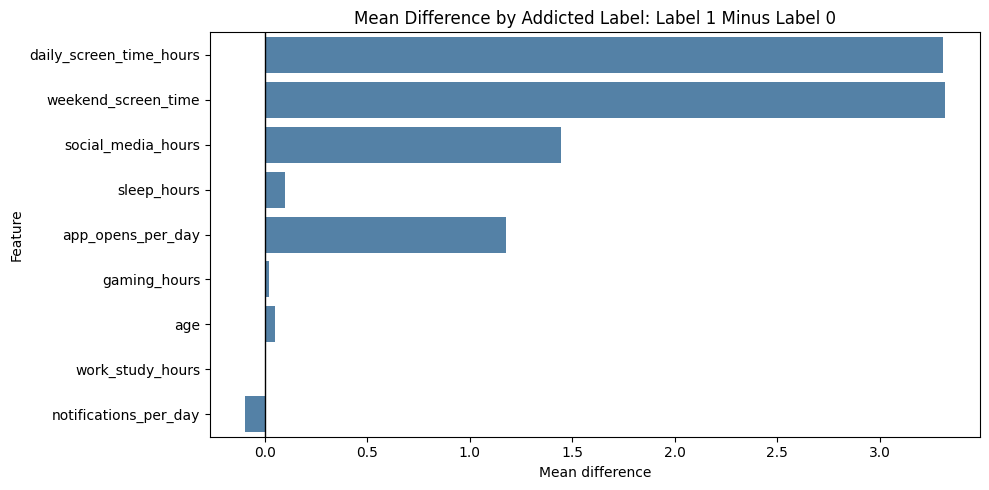

In [12]:
from scipy.stats import mannwhitneyu, ttest_ind

hypothesis_test_rows = []
for col in ['age'] + eda_numeric_columns:
    group_0 = df_prepared.loc[df_prepared['addicted_label'] == 0, col].dropna()
    group_1 = df_prepared.loc[df_prepared['addicted_label'] == 1, col].dropna()

    t_stat, t_p_value = ttest_ind(group_0, group_1, equal_var=False)
    u_stat, mw_p_value = mannwhitneyu(group_0, group_1, alternative='two-sided')

    hypothesis_test_rows.append({
        'feature': col,
        'mean_label_0': group_0.mean(),
        'mean_label_1': group_1.mean(),
        'median_label_0': group_0.median(),
        'median_label_1': group_1.median(),
        'mean_difference_1_minus_0': group_1.mean() - group_0.mean(),
        'welch_t_p_value': t_p_value,
        'mann_whitney_p_value': mw_p_value
    })

hypothesis_tests_df = (
    pd.DataFrame(hypothesis_test_rows)
    .assign(
        mann_whitney_significant=lambda frame: frame['mann_whitney_p_value'] < 0.05,
        welch_t_significant=lambda frame: frame['welch_t_p_value'] < 0.05
    )
    .sort_values(by='mann_whitney_p_value')
    .reset_index(drop=True)
)

print('Numeric feature tests comparing addicted_label groups:')
display(hypothesis_tests_df.round({
    'mean_label_0': 2,
    'mean_label_1': 2,
    'median_label_0': 2,
    'median_label_1': 2,
    'mean_difference_1_minus_0': 2,
    'welch_t_p_value': 6,
    'mann_whitney_p_value': 6
}))

plt.figure(figsize=(10, 5))
sns.barplot(
    data=hypothesis_tests_df,
    x='mean_difference_1_minus_0',
    y='feature',
    color='steelblue'
)
plt.axvline(0, color='black', linewidth=1)
plt.title('Mean Difference by Addicted Label: Label 1 Minus Label 0')
plt.xlabel('Mean difference')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


### Hypothesis Test Interpretation

The formal tests add statistical support to the descriptive EDA. Screen-time-related variables should be expected to rank highly because the later synthetic-rule diagnostic shows that the label is strongly tied to threshold-like usage behavior. Results with small p-values are still associations inside this dataset, not causal or clinical evidence.


### Age Subgroup Analysis

The dataset only covers ages 18 to 35, so age findings should not be generalized to teenagers, children, or older adults. Within the available range, split records into 18-22, 23-27, and 28-35 to check whether usage patterns and label rates differ by age group.


Age subgroup summary:


,age_group,rows,addicted_rate,daily_screen_time_mean,social_media_hours_mean,weekend_screen_time_mean,sleep_hours_mean,addicted_rate_percent
0,18-22,2078,0.7016,7.50,3.25,9.23,6.75,70.16
1,23-27,2057,0.7122,7.45,3.30,9.20,6.76,71.22
2,28-35,3365,0.7088,7.53,3.27,9.28,6.72,70.88


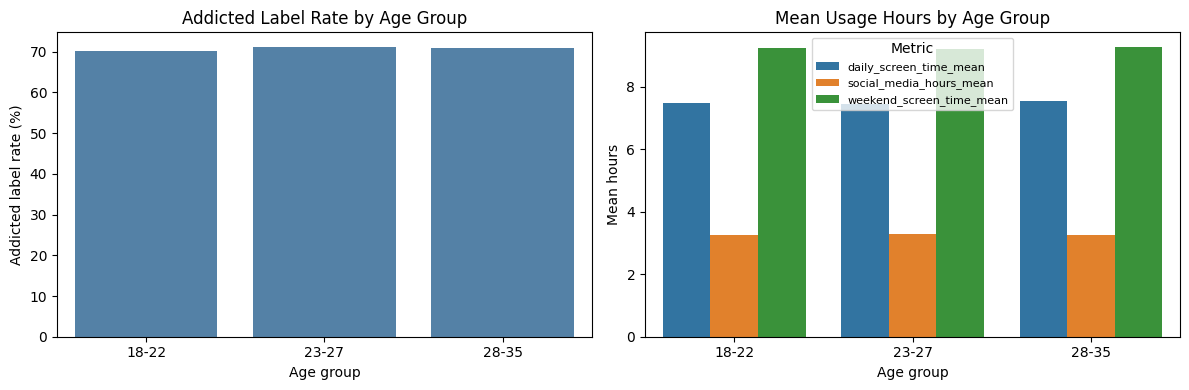

In [13]:
df_prepared['age_group'] = pd.cut(
    df_prepared['age'],
    bins=[17, 22, 27, 35],
    labels=['18-22', '23-27', '28-35'],
    include_lowest=True
)

age_group_summary = (
    df_prepared
    .groupby('age_group', observed=False)
    .agg(
        rows=('addicted_label', 'size'),
        addicted_rate=('addicted_label', 'mean'),
        daily_screen_time_mean=('daily_screen_time_hours', 'mean'),
        social_media_hours_mean=('social_media_hours', 'mean'),
        weekend_screen_time_mean=('weekend_screen_time', 'mean'),
        sleep_hours_mean=('sleep_hours', 'mean')
    )
    .reset_index()
)

age_group_summary['addicted_rate_percent'] = age_group_summary['addicted_rate'] * 100

print('Age subgroup summary:')
display(age_group_summary.round({
    'addicted_rate': 4,
    'addicted_rate_percent': 2,
    'daily_screen_time_mean': 2,
    'social_media_hours_mean': 2,
    'weekend_screen_time_mean': 2,
    'sleep_hours_mean': 2
}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(
    data=age_group_summary,
    x='age_group',
    y='addicted_rate_percent',
    color='steelblue',
    ax=axes[0]
)
axes[0].set_title('Addicted Label Rate by Age Group')
axes[0].set_xlabel('Age group')
axes[0].set_ylabel('Addicted label rate (%)')

age_usage_long = age_group_summary.melt(
    id_vars='age_group',
    value_vars=['daily_screen_time_mean', 'social_media_hours_mean', 'weekend_screen_time_mean'],
    var_name='metric',
    value_name='mean_hours'
)
sns.barplot(
    data=age_usage_long,
    x='age_group',
    y='mean_hours',
    hue='metric',
    ax=axes[1]
)
axes[1].set_title('Mean Usage Hours by Age Group')
axes[1].set_xlabel('Age group')
axes[1].set_ylabel('Mean hours')
axes[1].legend(title='Metric', fontsize=8)
plt.tight_layout()
plt.show()


### Age Subgroup Interpretation

Age subgrouping adds a demographic check that was missing from the original analysis. Because the age span is narrow and the target appears rule-generated, any age differences should be described as dataset-specific patterns rather than population-level conclusions.


### Numeric Range, Outlier, and Logical Consistency Check

Before relying on the distribution charts, check numeric ranges, simple IQR bounds, and basic time-budget consistency. This is not a reason to automatically remove rows; it is a sanity check for impossible values, synthetic-data artifacts, or extreme points that could distort interpretation.


In [14]:
range_check_columns = ['age'] + eda_numeric_columns

range_check_rows = []
for col in range_check_columns:
    q1 = df_prepared[col].quantile(0.25)
    q3 = df_prepared[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outside_iqr = ((df_prepared[col] < lower_bound) | (df_prepared[col] > upper_bound)).sum()
    range_check_rows.append({
        'column': col,
        'min': df_prepared[col].min(),
        'q1': q1,
        'median': df_prepared[col].median(),
        'q3': q3,
        'max': df_prepared[col].max(),
        'iqr': iqr,
        'iqr_lower_bound': lower_bound,
        'iqr_upper_bound': upper_bound,
        'outside_iqr_count': outside_iqr
    })

range_check_df = pd.DataFrame(range_check_rows)
display(range_check_df.round(2))

time_budget_total = (
    df_prepared['sleep_hours']
    + df_prepared['daily_screen_time_hours']
    + df_prepared['work_study_hours']
)
time_budget_violation_mask = time_budget_total > 24

component_exceeds_total_mask = df_prepared['usage_component_total_hours'] > df_prepared['daily_screen_time_hours']
single_component_gt_daily_mask = (
    (df_prepared['social_media_hours'] > df_prepared['daily_screen_time_hours'])
    | (df_prepared['gaming_hours'] > df_prepared['daily_screen_time_hours'])
    | (df_prepared['work_study_hours'] > df_prepared['daily_screen_time_hours'])
)

logical_check_summary = pd.DataFrame([
    {
        'check': 'sleep + daily screen time + work/study hours > 24',
        'affected_rows': int(time_budget_violation_mask.sum()),
        'affected_percent': time_budget_violation_mask.mean() * 100,
        'maximum_value': time_budget_total.max()
    },
    {
        'check': 'social + gaming + work/study hours > daily screen time',
        'affected_rows': int(component_exceeds_total_mask.sum()),
        'affected_percent': component_exceeds_total_mask.mean() * 100,
        'maximum_value': df_prepared['usage_component_total_hours'].max()
    },
    {
        'check': 'at least one component hour field > daily screen time',
        'affected_rows': int(single_component_gt_daily_mask.sum()),
        'affected_percent': single_component_gt_daily_mask.mean() * 100,
        'maximum_value': np.nan
    }
])

print('Logical consistency checks:')
display(logical_check_summary.round(2))

single_component_checks = {
    'social_media_hours_gt_daily_screen_time': (df_prepared['social_media_hours'] > df_prepared['daily_screen_time_hours']).sum(),
    'gaming_hours_gt_daily_screen_time': (df_prepared['gaming_hours'] > df_prepared['daily_screen_time_hours']).sum(),
    'work_study_hours_gt_daily_screen_time': (df_prepared['work_study_hours'] > df_prepared['daily_screen_time_hours']).sum()
}

print('Single component greater than daily screen time counts:')
display(pd.Series(single_component_checks, name='affected_rows').to_frame())


,column,min,q1,median,q3,max,iqr,iqr_lower_bound,iqr_upper_bound,outside_iqr_count
0,age,18.00,22.00,27.00,31.00,35.00,9.00,8.50,44.50,0
1,daily_screen_time_hours,3.00,5.22,7.52,9.81,12.00,4.59,-1.67,16.70,0
2,social_media_hours,0.50,1.91,3.27,4.63,6.00,2.72,-2.17,8.71,0
3,gaming_hours,0.00,1.02,2.04,2.99,4.00,1.97,-1.94,5.94,0
4,work_study_hours,0.50,1.85,3.23,4.64,6.00,2.79,-2.33,8.82,0
5,sleep_hours,4.50,5.63,6.72,7.84,9.00,2.21,2.32,11.16,0
6,notifications_per_day,20.00,76.00,134.00,191.00,250.00,115.00,-96.50,363.50,0
7,app_opens_per_day,15.00,55.00,98.00,140.00,180.00,85.00,-72.50,267.50,0
8,weekend_screen_time,3.58,6.96,9.26,11.54,14.88,4.58,0.09,18.41,0


Logical consistency checks:


,check,affected_rows,affected_percent,maximum_value
0,sleep + daily screen time + work/study hours > 24,156,2.08,26.46
1,social + gaming + work/study hours > daily scr...,4553,60.71,15.80
2,at least one component hour field > daily scre...,1140,15.20,NaN


Single component greater than daily screen time counts:


,affected_rows
social_media_hours_gt_daily_screen_time,685
gaming_hours_gt_daily_screen_time,111
work_study_hours_gt_daily_screen_time,683


### Numeric Range Check Interpretation

The numeric values stay within plausible simulated ranges for the individual columns, but the cross-field checks reveal important logical contradictions. Some rows exceed a 24-hour daily budget when sleep, daily screen time, and work/study hours are added together. In many rows, the component-hour fields also exceed total daily screen time, and some individual component fields are larger than total screen time.

This suggests the dataset is likely synthetic or loosely generated, and that the component-hour fields should not be interpreted as strict parts of a daily-screen-time whole. The notebook keeps the rows because there is no reliable correction rule, but the aggregate and intensity features are treated as diagnostic/sensitivity features rather than trusted final-model inputs. The age range is also narrow, so conclusions apply only to the 18-35 age span represented in this dataset.


### EDA Charts

These charts focus on whether the prepared data shows visible differences between users labeled as addicted and non-addicted. The main things to check are target imbalance, whether screen-time-related variables separate the two target groups, whether sleep and notification behavior look different, and whether categorical variables such as stress level, academic/work impact, and gender show clear patterns with `addicted_label`.


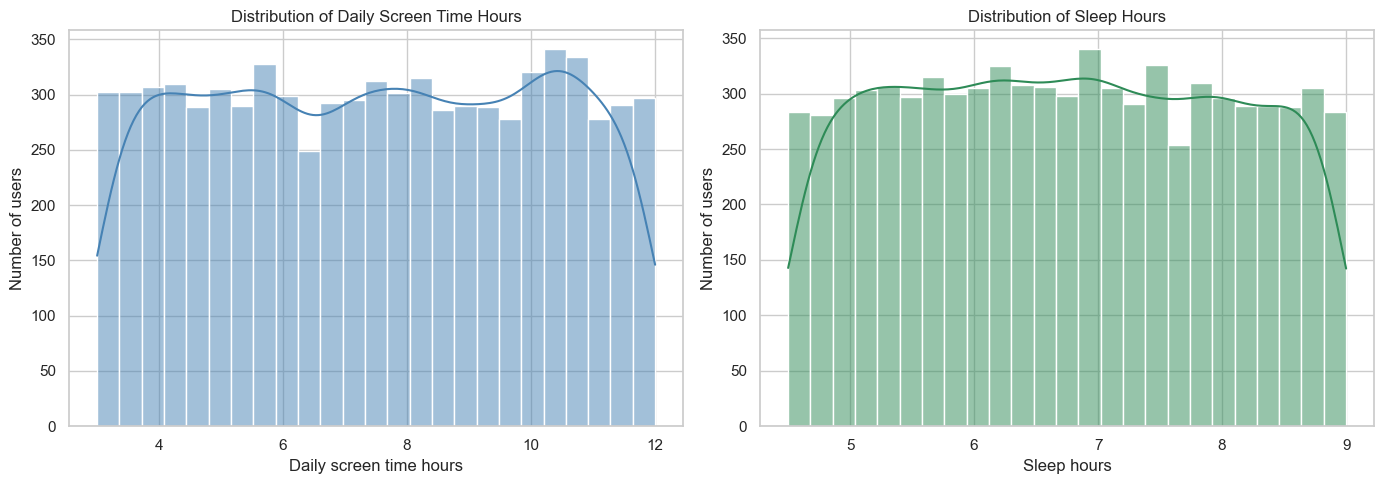

In [15]:
# Distribution charts for daily screen time and sleep hours
sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df_prepared,
    x='daily_screen_time_hours',
    bins=25,
    kde=True,
    ax=axes[0],
    color='steelblue'
)
axes[0].set_title('Distribution of Daily Screen Time Hours')
axes[0].set_xlabel('Daily screen time hours')
axes[0].set_ylabel('Number of users')

sns.histplot(
    data=df_prepared,
    x='sleep_hours',
    bins=25,
    kde=True,
    ax=axes[1],
    color='seagreen'
)
axes[1].set_title('Distribution of Sleep Hours')
axes[1].set_xlabel('Sleep hours')
axes[1].set_ylabel('Number of users')

plt.tight_layout()
plt.show()


### Distribution Chart Observations

Daily screen time ranges from about 3.00 to 11.99 hours, while sleep hours range from about 4.50 to 9.00 hours. These ungrouped distributions show the overall spread of the variables; the target-group separation is assessed in the comparison charts and grouped summaries below.

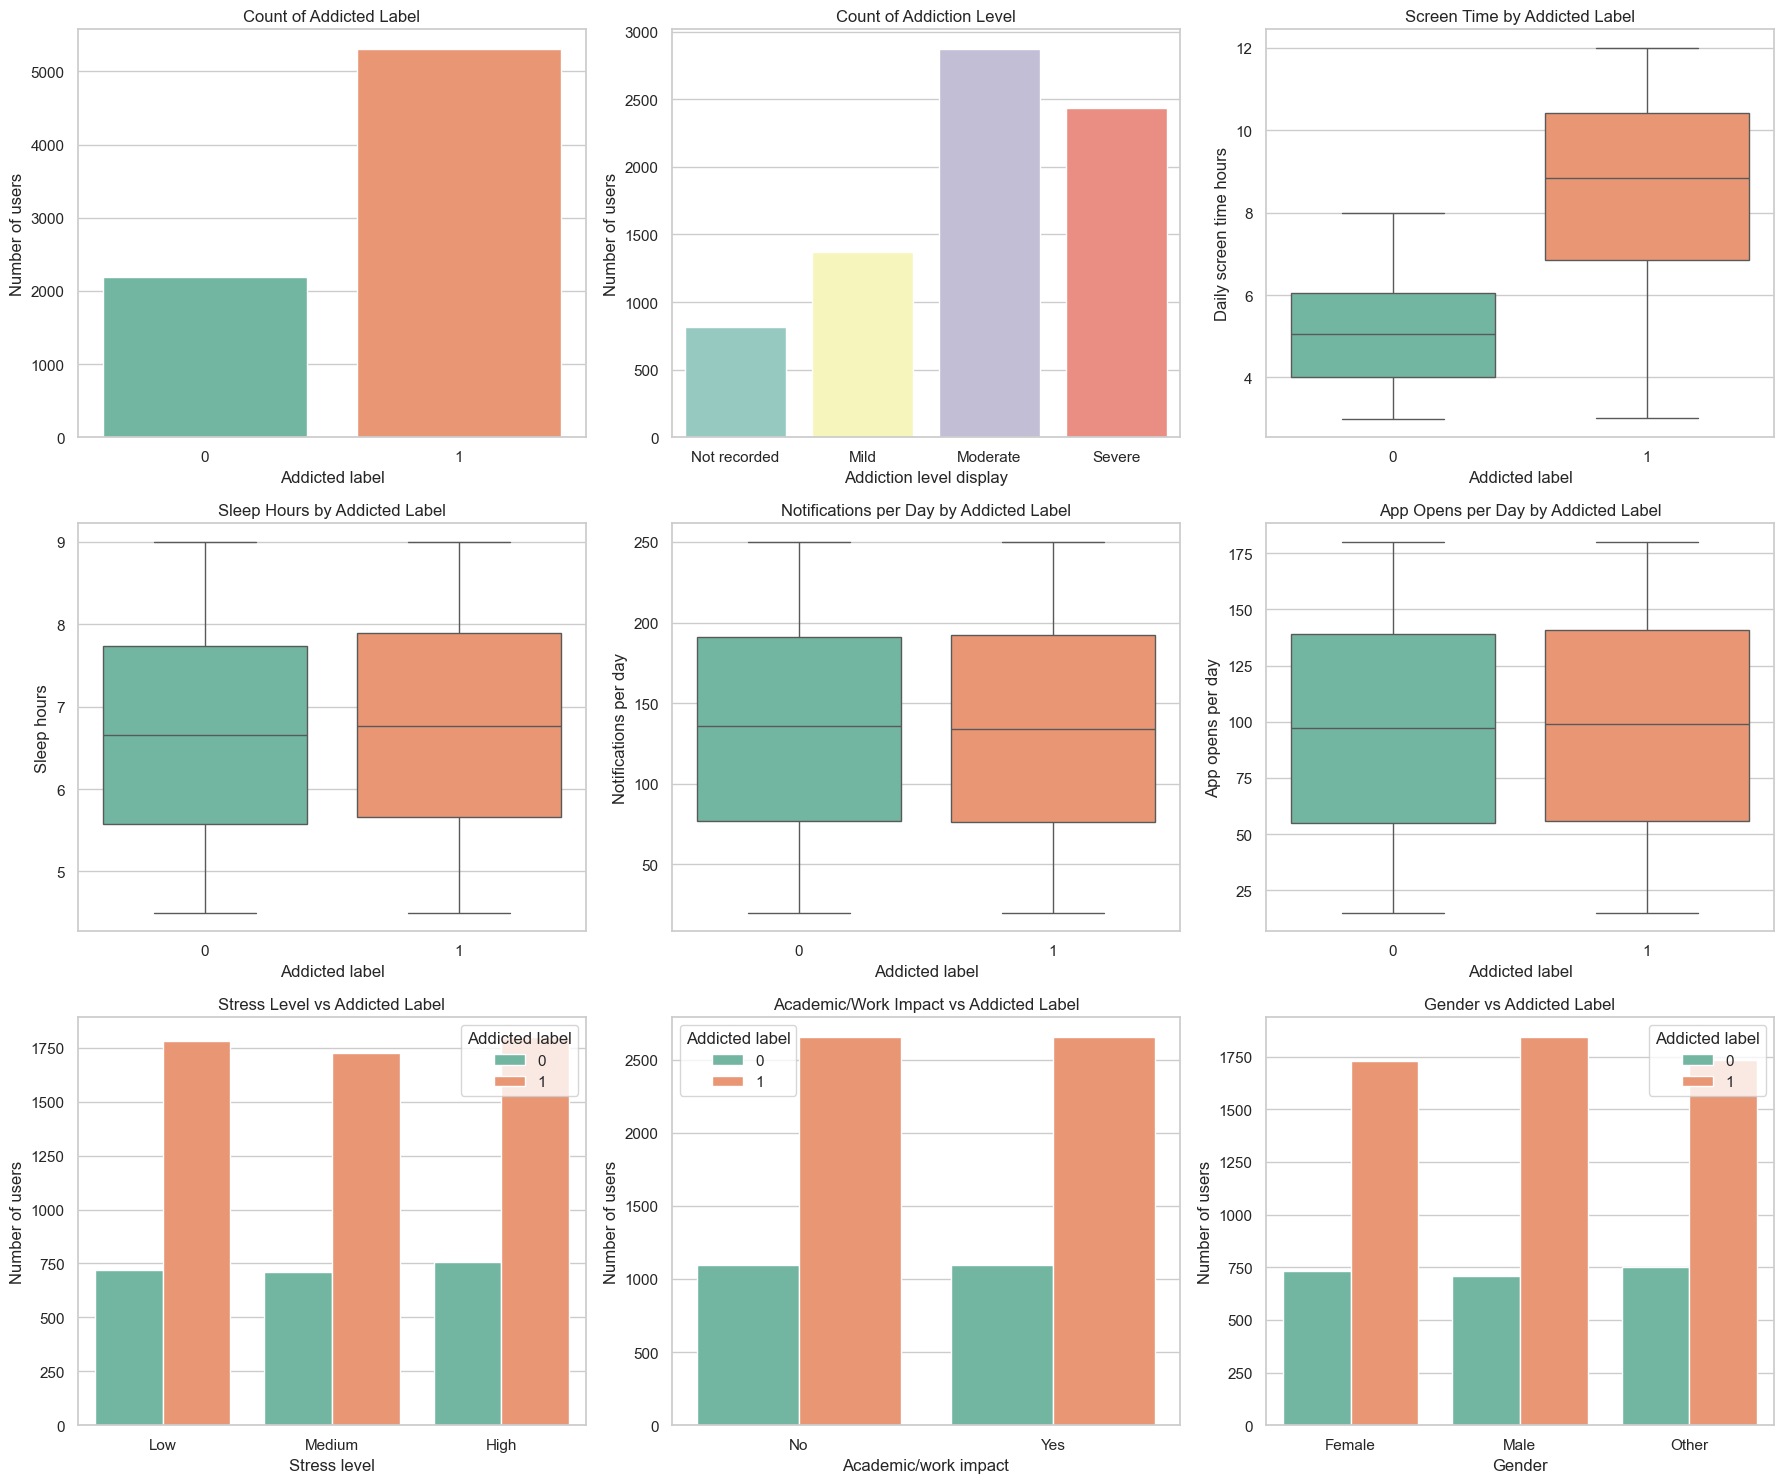

In [16]:
# Count charts and comparison charts by addicted_label
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

sns.countplot(data=df_prepared, x='addicted_label', ax=axes[0], palette='Set2', hue='addicted_label', legend=False)
axes[0].set_title('Count of Addicted Label')
axes[0].set_xlabel('Addicted label')
axes[0].set_ylabel('Number of users')

sns.countplot(data=df_prepared, x='addiction_level_display', ax=axes[1], order=['Not recorded', 'Mild', 'Moderate', 'Severe'], palette='Set3', hue='addiction_level_display', legend=False)
axes[1].set_title('Count of Addiction Level')
axes[1].set_xlabel('Addiction level display')
axes[1].set_ylabel('Number of users')

sns.boxplot(data=df_prepared, x='addicted_label', y='daily_screen_time_hours', ax=axes[2], palette='Set2', hue='addicted_label', legend=False)
axes[2].set_title('Screen Time by Addicted Label')
axes[2].set_xlabel('Addicted label')
axes[2].set_ylabel('Daily screen time hours')

sns.boxplot(data=df_prepared, x='addicted_label', y='sleep_hours', ax=axes[3], palette='Set2', hue='addicted_label', legend=False)
axes[3].set_title('Sleep Hours by Addicted Label')
axes[3].set_xlabel('Addicted label')
axes[3].set_ylabel('Sleep hours')

sns.boxplot(data=df_prepared, x='addicted_label', y='notifications_per_day', ax=axes[4], palette='Set2', hue='addicted_label', legend=False)
axes[4].set_title('Notifications per Day by Addicted Label')
axes[4].set_xlabel('Addicted label')
axes[4].set_ylabel('Notifications per day')

sns.boxplot(data=df_prepared, x='addicted_label', y='app_opens_per_day', ax=axes[5], palette='Set2', hue='addicted_label', legend=False)
axes[5].set_title('App Opens per Day by Addicted Label')
axes[5].set_xlabel('Addicted label')
axes[5].set_ylabel('App opens per day')

sns.countplot(data=df_prepared, x='stress_level', hue='addicted_label', ax=axes[6], order=['Low', 'Medium', 'High'], palette='Set2')
axes[6].set_title('Stress Level vs Addicted Label')
axes[6].set_xlabel('Stress level')
axes[6].set_ylabel('Number of users')
axes[6].legend(title='Addicted label')

sns.countplot(data=df_prepared, x='academic_work_impact', hue='addicted_label', ax=axes[7], order=['No', 'Yes'], palette='Set2')
axes[7].set_title('Academic/Work Impact vs Addicted Label')
axes[7].set_xlabel('Academic/work impact')
axes[7].set_ylabel('Number of users')
axes[7].legend(title='Addicted label')

sns.countplot(data=df_prepared, x='gender', hue='addicted_label', ax=axes[8], order=['Female', 'Male', 'Other'], palette='Set2')
axes[8].set_title('Gender vs Addicted Label')
axes[8].set_xlabel('Gender')
axes[8].set_ylabel('Number of users')
axes[8].legend(title='Addicted label')

plt.tight_layout()
plt.show()


### Comparison Chart Observations

The count chart confirms that `addicted_label = 1` is the majority class. The boxplots show clearer separation for daily screen time than for sleep hours, notifications, or app opens. The categorical count charts for stress level, academic/work impact, and gender do not show strong visible separation across the two target labels. The earlier normalized gender chart is the better visual for comparing gender target rates because each gender category is scaled to 100%.

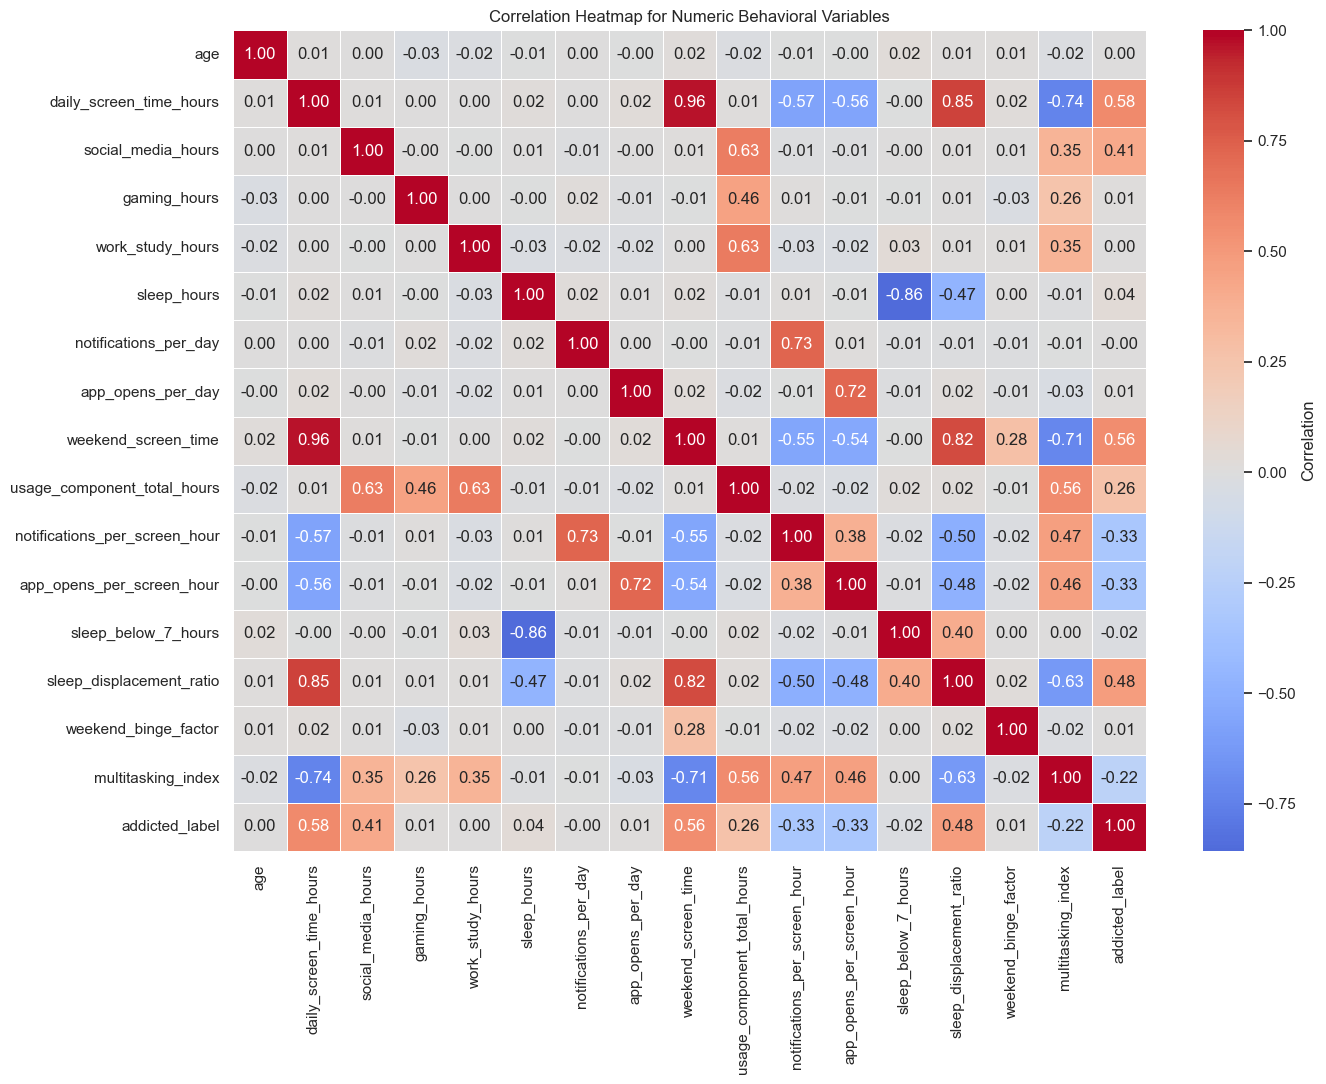

Correlation with addicted_label, sorted by absolute strength:


,correlation_with_addicted_label
daily_screen_time_hours,0.577
weekend_screen_time,0.555
sleep_displacement_ratio,0.485
social_media_hours,0.414
notifications_per_screen_hour,-0.329
app_opens_per_screen_hour,-0.329
usage_component_total_hours,0.264
multitasking_index,-0.224
sleep_hours,0.035
sleep_below_7_hours,-0.022


Domain-engineered feature validation:


,correlation_with_addicted_label
sleep_displacement_ratio,0.485
weekend_binge_factor,0.006
multitasking_index,-0.224


In [17]:
# Correlation heatmap for numeric variables
correlation_columns = [
    'age',
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time',
    'usage_component_total_hours',
    'notifications_per_screen_hour',
    'app_opens_per_screen_hour',
    'sleep_below_7_hours',
    'sleep_displacement_ratio',
    'weekend_binge_factor',
    'multitasking_index',
    'addicted_label'
]

correlation_matrix = df_prepared[correlation_columns].corr(numeric_only=True)

plt.figure(figsize=(14, 11))
sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Correlation'}
)
plt.title('Correlation Heatmap for Numeric Behavioral Variables')
plt.tight_layout()
plt.show()

print('Correlation with addicted_label, sorted by absolute strength:')
correlation_with_target = (
    correlation_matrix['addicted_label']
    .drop('addicted_label')
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .round(3)
)
display(correlation_with_target.rename('correlation_with_addicted_label').to_frame())

domain_feature_summary = correlation_with_target.loc[
    ['sleep_displacement_ratio', 'weekend_binge_factor', 'multitasking_index']
].rename('correlation_with_addicted_label').to_frame()

print('Domain-engineered feature validation:')
display(domain_feature_summary)


### Correlation Heatmap Observations

The strongest numeric relationships with `addicted_label` are `daily_screen_time_hours` (about 0.577), `weekend_screen_time` (about 0.555), `sleep_displacement_ratio` (about 0.485), and `social_media_hours` (about 0.414). The sleep displacement ratio is empirically useful, but it is still derived from two existing columns and should be treated as predictive rather than causal.

The weekend binge factor has almost no relationship with the target, showing why intuitive engineered features still need validation. The multitasking index has a moderate negative relationship with the target, but its interpretation is weakened by the component-hour contradictions found in the logical consistency check.

Gender was assessed separately as a categorical variable using target rates, Cramer's V, and a normalized chart. It is not included in this numeric correlation heatmap or in the predictive model.

Correlation does not prove causation, but it helps identify non-leaking variables that may be useful for classification models.


### Unsupervised Usage Clustering

Run a small clustering analysis on behavioral features to look for usage segments beyond the binary target. The clustering does not use `addicted_label`, `addiction_level`, identifiers, or gender. The target is compared afterward only to describe how the discovered segments overlap with the provided label.


K-means cluster selection summary:


,k,inertia,silhouette_score
0,2,56462.4596,0.1507
1,3,53263.6281,0.1089
2,4,50455.6194,0.0919
3,5,48578.2622,0.0871


Selected k by highest silhouette score: 2
Usage cluster profile:


,usage_cluster,rows,addicted_rate,age_mean,daily_screen_time_mean,social_media_hours_mean,gaming_hours_mean,work_study_hours_mean,sleep_hours_mean,notifications_per_day_mean,app_opens_per_day_mean,weekend_screen_time_mean,addicted_rate_percent
0,0,3684,0.44,26.46,5.21,3.23,2.01,3.23,6.71,134.02,96.51,6.89,44.46
1,1,3816,0.96,26.68,9.71,3.32,2.02,3.25,6.76,134.48,99.11,11.52,96.17


Addicted label share within each usage cluster:


addicted_label,0,1
usage_cluster,,
0,55.54,44.46
1,3.83,96.17


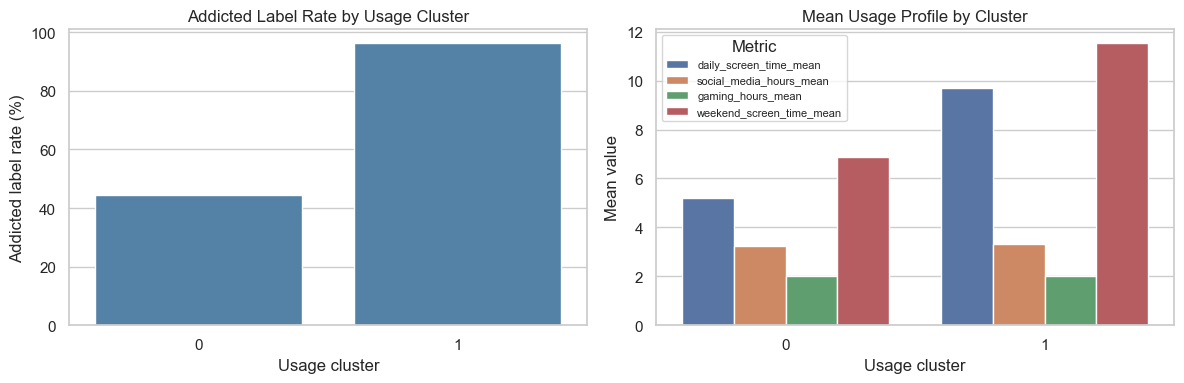

In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

cluster_feature_columns = [
    'age',
    'daily_screen_time_hours',
    'social_media_hours',
    'gaming_hours',
    'work_study_hours',
    'sleep_hours',
    'notifications_per_day',
    'app_opens_per_day',
    'weekend_screen_time'
]

cluster_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cluster_matrix = cluster_preprocessor.fit_transform(df_prepared[cluster_feature_columns])

cluster_selection_rows = []
for k in range(2, 6):
    kmeans_candidate = KMeans(n_clusters=k, random_state=42, n_init=20)
    candidate_labels = kmeans_candidate.fit_predict(cluster_matrix)
    cluster_selection_rows.append({
        'k': k,
        'inertia': kmeans_candidate.inertia_,
        'silhouette_score': silhouette_score(cluster_matrix, candidate_labels)
    })

cluster_selection_df = pd.DataFrame(cluster_selection_rows)
best_cluster_k = int(cluster_selection_df.sort_values(by='silhouette_score', ascending=False).iloc[0]['k'])

print('K-means cluster selection summary:')
display(cluster_selection_df.round(4))
print(f'Selected k by highest silhouette score: {best_cluster_k}')

kmeans_model = KMeans(n_clusters=best_cluster_k, random_state=42, n_init=20)
df_prepared['usage_cluster'] = kmeans_model.fit_predict(cluster_matrix)

cluster_profile = (
    df_prepared
    .groupby('usage_cluster')
    .agg(
        rows=('addicted_label', 'size'),
        addicted_rate=('addicted_label', 'mean'),
        age_mean=('age', 'mean'),
        daily_screen_time_mean=('daily_screen_time_hours', 'mean'),
        social_media_hours_mean=('social_media_hours', 'mean'),
        gaming_hours_mean=('gaming_hours', 'mean'),
        work_study_hours_mean=('work_study_hours', 'mean'),
        sleep_hours_mean=('sleep_hours', 'mean'),
        notifications_per_day_mean=('notifications_per_day', 'mean'),
        app_opens_per_day_mean=('app_opens_per_day', 'mean'),
        weekend_screen_time_mean=('weekend_screen_time', 'mean')
    )
    .reset_index()
)
cluster_profile['addicted_rate_percent'] = cluster_profile['addicted_rate'] * 100

print('Usage cluster profile:')
display(cluster_profile.round(2))

cluster_target_table = pd.crosstab(
    df_prepared['usage_cluster'],
    df_prepared['addicted_label'],
    normalize='index'
).mul(100).round(2)

print('Addicted label share within each usage cluster:')
display(cluster_target_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(
    data=cluster_profile,
    x='usage_cluster',
    y='addicted_rate_percent',
    color='steelblue',
    ax=axes[0]
)
axes[0].set_title('Addicted Label Rate by Usage Cluster')
axes[0].set_xlabel('Usage cluster')
axes[0].set_ylabel('Addicted label rate (%)')

cluster_usage_long = cluster_profile.melt(
    id_vars='usage_cluster',
    value_vars=['daily_screen_time_mean', 'social_media_hours_mean', 'gaming_hours_mean', 'weekend_screen_time_mean'],
    var_name='metric',
    value_name='mean_value'
)
sns.barplot(
    data=cluster_usage_long,
    x='usage_cluster',
    y='mean_value',
    hue='metric',
    ax=axes[1]
)
axes[1].set_title('Mean Usage Profile by Cluster')
axes[1].set_xlabel('Usage cluster')
axes[1].set_ylabel('Mean value')
axes[1].legend(title='Metric', fontsize=8)
plt.tight_layout()
plt.show()


### Clustering Interpretation

The clustering is exploratory and should be read as a behavioral segmentation check, not a replacement for supervised modeling. Comparing clusters with `addicted_label` helps show whether the binary label captures several usage profiles or mainly tracks high screen-time and social-media thresholds.


### Phase 3 Questions Answered

1. The target variable is imbalanced. About 70.77% of the prepared rows have `addicted_label = 1`, while about 29.23% have `addicted_label = 0`.
2. Addicted and non-addicted groups appear different in screen time. The `addicted_label = 1` group has higher average daily screen time (8.47 vs 5.16 hours) and weekend screen time (10.21 vs 6.89 hours).
3. Addicted and non-addicted groups do not appear very different in sleep hours. The averages and medians are close, although the derived `sleep_displacement_ratio` is more strongly related to the target because it combines screen time and sleep.
4. `stress_level`, `academic_work_impact`, and `gender` do not show strong separation with `addicted_label` in the grouped summaries, row percentages, or charts. Gender is therefore excluded from modeling after the diagnostic check.
5. The variables that seem most useful for modeling are `daily_screen_time_hours`, `weekend_screen_time`, `social_media_hours`, and `sleep_displacement_ratio`. Aggregate and intensity features are interpreted cautiously because component-hour fields sometimes contradict total daily screen time. `addiction_level` should not be used for prediction because it behaves like a target proxy.


### Person 3 Handoff to Person 4

1. Main EDA observations: `addicted_label = 1` is the majority class; daily screen time, weekend screen time, social media hours, and sleep displacement ratio are higher for the `addicted_label = 1` group; sleep hours, notifications, app opens, gender, stress level, and academic/work impact show weaker differences in the descriptive summaries.
2. Data-quality caveat: individual numeric ranges look plausible, but cross-field checks show logical contradictions in the time fields. Some rows exceed a 24-hour budget, and many component-hour fields exceed total daily screen time.
3. Target balance: the target is imbalanced, with about 70.77% labeled `1` and 29.23% labeled `0`. Person 4 should use `stratify=y` during the train/test split and compare models against a majority-class baseline.
4. Features that seem important from EDA: `daily_screen_time_hours`, `weekend_screen_time`, `social_media_hours`, and `sleep_displacement_ratio` may be useful. The aggregate, ratio, and multitasking features should be interpreted carefully because they are derived from potentially inconsistent time fields.
5. Gender decision: gender showed weak target separation and is excluded from the predictive model. This keeps all rows without imputing or forcing `Other` into a binary encoding.
6. Leakage warning: `addiction_level` should not be used in the predictive model. In this prepared dataset it behaves like a target proxy, with `Mild` and `Not recorded` aligned to `addicted_label = 0` and `Moderate` and `Severe` aligned to `addicted_label = 1`.
7. `df_prepared`, `X`, `X_unencoded`, `y`, and `model_feature_columns` are ready for Phase 4 predictive analytics. Encoding, imputation, and scaling should happen inside sklearn pipelines.


## 4. Predictive Analytics - Person 4

This section builds simple classification models to predict `addicted_label` using the non-leaking feature set prepared by Person 2. The main goal is to compare several course-appropriate models, choose one suitable model, tune only that selected model, and interpret the results clearly.

Important leakage rule: `transaction_id`, `user_id`, `gender`, `addiction_level`, and `addicted_label` are not used as input features. `addiction_level` is excluded because Person 3 showed that it behaves like a target proxy.

### Modeling Setup and Leakage Check

The train/test split uses 80% training data and 20% testing data with `random_state=42`. Because the target is imbalanced, the split uses `stratify=y` so the class proportions stay similar in both sets.

The feature matrix is intentionally left unencoded at this point. Numeric imputation, scaling, and categorical one-hot encoding are fit inside sklearn pipelines during cross-validation so preprocessing does not learn from held-out test rows.


In [19]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RepeatedStratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    roc_auc_score,
    RocCurveDisplay,
    make_scorer
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# Confirm the modeling feature matrix follows the project leakage and gender-exclusion rules.
leakage_columns = ['transaction_id', 'user_id', 'gender', 'addiction_level', 'addiction_level_display', 'addicted_label']
leakage_columns_in_X = [col for col in leakage_columns if col in X.columns]

print('Excluded/leakage columns found in X:')
print(leakage_columns_in_X if leakage_columns_in_X else 'None')

print()
print('Unencoded feature matrix and target shape:')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

print()
print('Target class balance before split:')
target_balance = pd.concat(
    [
        y.value_counts().sort_index().rename('count'),
        (y.value_counts(normalize=True).sort_index() * 100).round(2).rename('percentage')
    ],
    axis=1
)
display(target_balance)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print()
print('Train/test shapes:')
print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test: {y_test.shape}')

print()
print('Target balance in test set:')
test_balance = pd.concat(
    [
        y_test.value_counts().sort_index().rename('count'),
        (y_test.value_counts(normalize=True).sort_index() * 100).round(2).rename('percentage')
    ],
    axis=1
)
display(test_balance)


Excluded/leakage columns found in X:
None

Unencoded feature matrix and target shape:
X shape: (7500, 18)
y shape: (7500,)

Target class balance before split:


,count,percentage
addicted_label,,
0,2192,29.23
1,5308,70.77



Train/test shapes:
X_train: (6000, 18)
X_test: (1500, 18)
y_train: (6000,)
y_test: (1500,)

Target balance in test set:


,count,percentage
addicted_label,,
0,438,29.2
1,1062,70.8


### Baseline and First-Pass Model Comparison

A majority-class baseline is included so the classification models must beat a simple rule that always predicts the most common class. Logistic regression, decision tree, Naive Bayes, KNN, and a small neural network are compared using 5-fold cross-validation inside the training data.

Because the target is imbalanced and both labels matter, model-family selection uses macro-F1 as the primary selection metric. Class-1 F1, balanced accuracy, class-0 recall, and class-1 recall are still reported so the class-level trade-offs stay visible. The held-out test set remains untouched for final model reporting.

Each candidate model is wrapped in a preprocessing pipeline. Numeric imputation/scaling and categorical one-hot encoding are fit only on each training fold, and `OneHotEncoder(handle_unknown='ignore', drop='first')` avoids future category shape errors and the full dummy-variable trap for linear baselines.


Training-only cross-validation model comparison:


,model,cv_macro_f1_mean,cv_macro_f1_std,cv_balanced_accuracy_mean,cv_roc_auc_mean,cv_roc_auc_std,cv_f1_1_mean,cv_recall_0_mean,cv_recall_1_mean
0,Decision tree,0.9243,0.0115,0.9241,0.9241,0.0154,0.9559,0.8917,0.9564
1,Neural network,0.8985,0.0123,0.8927,0.9741,0.0053,0.9422,0.8335,0.9520
2,Logistic regression,0.8896,0.0121,0.8848,0.9658,0.0054,0.9368,0.8244,0.9451
3,KNN,0.8687,0.0128,0.8602,0.9469,0.0069,0.9263,0.7788,0.9416
4,Naive Bayes,0.8187,0.0108,0.8343,0.9216,0.0052,0.8855,0.8124,0.8561
5,Majority class baseline,0.4144,0.0001,0.5000,0.5000,0.0000,0.8288,0.0000,1.0000


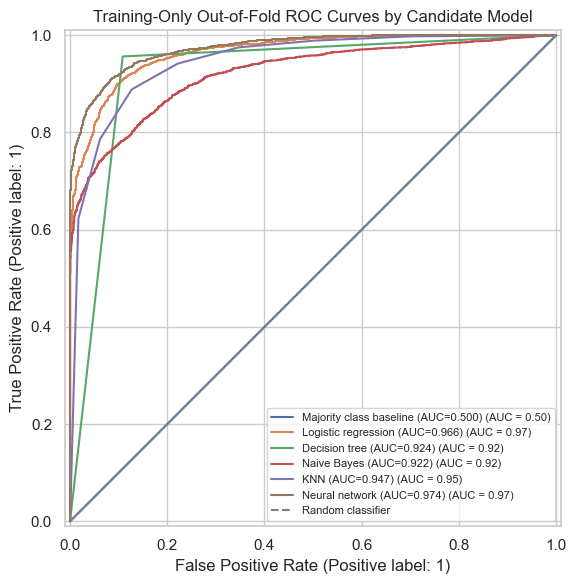

Training-only out-of-fold ROC-AUC by candidate model:


,model,training_out_of_fold_roc_auc
0,Neural network,0.9742
1,Logistic regression,0.9656
2,KNN,0.9468
3,Decision tree,0.9241
4,Naive Bayes,0.9217
5,Majority class baseline,0.5000


Selected model family from training-only CV using macro-F1: Decision tree


In [20]:
def get_positive_class_scores(fitted_model, X_eval):
    if hasattr(fitted_model, 'predict_proba'):
        return fitted_model.predict_proba(X_eval)[:, 1]
    if hasattr(fitted_model, 'decision_function'):
        return fitted_model.decision_function(X_eval)
    raise AttributeError('Model does not expose predict_proba or decision_function for ROC-AUC.')


def evaluate_classifier(model_name, fitted_model, X_eval, y_eval):
    predictions = fitted_model.predict(X_eval)
    tn, fp, fn, tp = confusion_matrix(y_eval, predictions).ravel()
    metrics = {
        'model': model_name,
        'accuracy': accuracy_score(y_eval, predictions),
        'balanced_accuracy': balanced_accuracy_score(y_eval, predictions),
        'precision_1': precision_score(y_eval, predictions, zero_division=0),
        'recall_1': recall_score(y_eval, predictions, zero_division=0),
        'recall_0': recall_score(y_eval, predictions, pos_label=0, zero_division=0),
        'f1_1': f1_score(y_eval, predictions, zero_division=0),
        'macro_f1': f1_score(y_eval, predictions, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_eval, predictions, average='weighted', zero_division=0),
        'true_negative': tn,
        'false_positive': fp,
        'false_negative': fn,
        'true_positive': tp
    }
    try:
        metrics['roc_auc'] = roc_auc_score(y_eval, get_positive_class_scores(fitted_model, X_eval))
    except AttributeError:
        metrics['roc_auc'] = np.nan
    return metrics

def build_preprocessor(numeric_features, categorical_features):
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
    ])

    return ColumnTransformer([
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

def build_model_pipeline(model, feature_columns):
    numeric_features = [col for col in feature_columns if col not in categorical_model_features]
    preprocessing = build_preprocessor(numeric_features, categorical_model_features)
    return Pipeline([
        ('preprocess', preprocessing),
        ('model', model)
    ])

candidate_models = {
    'Majority class baseline': DummyClassifier(strategy='most_frequent'),
    'Logistic regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'Neural network': MLPClassifier(
        hidden_layer_sizes=(32,),
        max_iter=1000,
        random_state=42,
        early_stopping=True
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scoring = {
    'f1_1': 'f1',
    'macro_f1': 'f1_macro',
    'balanced_accuracy': 'balanced_accuracy',
    'roc_auc': 'roc_auc',
    'recall_0': make_scorer(recall_score, pos_label=0, zero_division=0),
    'recall_1': make_scorer(recall_score, pos_label=1, zero_division=0)
}

cv_results = []
for model_name, model in candidate_models.items():
    model_pipeline = build_model_pipeline(model, model_feature_columns)
    scores = cross_validate(model_pipeline, X_train, y_train, cv=cv, scoring=cv_scoring, n_jobs=None)
    cv_results.append({
        'model': model_name,
        'cv_macro_f1_mean': scores['test_macro_f1'].mean(),
        'cv_macro_f1_std': scores['test_macro_f1'].std(),
        'cv_balanced_accuracy_mean': scores['test_balanced_accuracy'].mean(),
        'cv_roc_auc_mean': scores['test_roc_auc'].mean(),
        'cv_roc_auc_std': scores['test_roc_auc'].std(),
        'cv_f1_1_mean': scores['test_f1_1'].mean(),
        'cv_recall_0_mean': scores['test_recall_0'].mean(),
        'cv_recall_1_mean': scores['test_recall_1'].mean()
    })

selection_metric = 'cv_macro_f1_mean'
cv_model_results_df = (
    pd.DataFrame(cv_results)
    .sort_values(by=[selection_metric, 'cv_balanced_accuracy_mean', 'cv_f1_1_mean'], ascending=False)
    .reset_index(drop=True)
)

print('Training-only cross-validation model comparison:')
display(cv_model_results_df.round(4))

training_roc_rows = []
fig, ax = plt.subplots(figsize=(8, 6))
for model_name, model in candidate_models.items():
    model_pipeline = build_model_pipeline(model, model_feature_columns)
    out_of_fold_scores = cross_val_predict(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,
        method='predict_proba',
        n_jobs=None
    )[:, 1]
    out_of_fold_auc = roc_auc_score(y_train, out_of_fold_scores)
    training_roc_rows.append({
        'model': model_name,
        'training_out_of_fold_roc_auc': out_of_fold_auc
    })
    RocCurveDisplay.from_predictions(
        y_train,
        out_of_fold_scores,
        name=f'{model_name} (AUC={out_of_fold_auc:.3f})',
        ax=ax
    )

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
ax.set_title('Training-Only Out-of-Fold ROC Curves by Candidate Model')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

training_roc_auc_df = (
    pd.DataFrame(training_roc_rows)
    .sort_values(by='training_out_of_fold_roc_auc', ascending=False)
    .reset_index(drop=True)
)

print('Training-only out-of-fold ROC-AUC by candidate model:')
display(training_roc_auc_df.round(4))

selected_model_name = cv_model_results_df.loc[0, 'model']
print(f'Selected model family from training-only CV using macro-F1: {selected_model_name}')


### First-Pass Model Interpretation

Model family selection is based on 5-fold cross-validation inside the training data, not the held-out test set. Macro-F1 is used as the primary selection metric because the target is imbalanced and the minority class should not disappear behind the majority-class F1-score.

The decision tree has the strongest training-only macro-F1 score and remains a good fit for the assignment because it is both high-performing and explainable. Gender is not part of any candidate model. The earlier gender diagnostic showed weak association with `addicted_label`, so excluding it keeps the full dataset while avoiding unnecessary demographic features.

The model-comparison table now includes ROC-AUC in addition to macro-F1 and balanced accuracy. ROC curves are generated from out-of-fold training predictions, so they compare threshold-independent discrimination without using the held-out test set for model-family selection.


### Tune the Selected Model

Only the selected decision tree family is tuned. The grid search uses 5-fold cross-validation on the training data and optimizes macro-F1 because both target classes matter. The preprocessing pipeline is included inside the grid search, so imputation, scaling, and encoding are learned only from the training folds. The held-out test set is still reserved for the final recommended model only.


In [21]:
decision_tree_param_grid = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [2, 3, 4, 5, None],
    'model__min_samples_leaf': [1, 5, 10, 20]
}

full_tree_pipeline = build_model_pipeline(
    DecisionTreeClassifier(random_state=42),
    model_feature_columns
)

decision_tree_grid = GridSearchCV(
    estimator=full_tree_pipeline,
    param_grid=decision_tree_param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=None
)

decision_tree_grid.fit(X_train, y_train)

best_tree_model = decision_tree_grid.best_estimator_

print('Best decision tree parameters using all candidate engineered features:')
print(decision_tree_grid.best_params_)
print(f"Best cross-validation macro-F1 score: {decision_tree_grid.best_score_:.4f}")


Best decision tree parameters using all candidate engineered features:
{'model__criterion': 'entropy', 'model__max_depth': 2, 'model__min_samples_leaf': 1}
Best cross-validation macro-F1 score: 0.9277


### Engineered Feature Sensitivity Check

Because some engineered features are derived from internally inconsistent component-hour fields, run a sensitivity model without the aggregate/intensity features most affected by those contradictions. The final feature set is selected using training-only cross-validation and interpretability, not held-out test performance.


In [22]:
sensitivity_excluded_features = [
    'usage_component_total_hours',
    'notifications_per_screen_hour',
    'app_opens_per_screen_hour',
    'weekend_binge_factor',
    'multitasking_index'
]

sensitivity_feature_columns = [
    col for col in model_feature_columns
    if col not in sensitivity_excluded_features
]

X_sensitivity = df_prepared[sensitivity_feature_columns].copy()

X_sensitivity_train, X_sensitivity_test, y_sensitivity_train, y_sensitivity_test = train_test_split(
    X_sensitivity,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

sensitivity_tree_pipeline = build_model_pipeline(
    DecisionTreeClassifier(random_state=42),
    sensitivity_feature_columns
)

sensitivity_grid = GridSearchCV(
    estimator=sensitivity_tree_pipeline,
    param_grid=decision_tree_param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=None
)

sensitivity_grid.fit(X_sensitivity_train, y_sensitivity_train)
sensitivity_tree_model = sensitivity_grid.best_estimator_

feature_set_cv_summary = pd.DataFrame([
    {
        'feature_set': 'Full feature set with all engineered features',
        'feature_count': len(model_feature_columns),
        'cv_macro_f1': decision_tree_grid.best_score_,
        'best_params': decision_tree_grid.best_params_
    },
    {
        'feature_set': 'Interpretable feature set without unreliable aggregate/intensity features',
        'feature_count': len(sensitivity_feature_columns),
        'cv_macro_f1': sensitivity_grid.best_score_,
        'best_params': sensitivity_grid.best_params_
    }
])

print('Training-only feature-set comparison:')
display(feature_set_cv_summary.round({'cv_macro_f1': 4}))

cv_tolerance = 0.002
if sensitivity_grid.best_score_ >= decision_tree_grid.best_score_ - cv_tolerance:
    recommended_final_model = sensitivity_tree_model
    recommended_final_X_train = X_sensitivity_train
    recommended_final_X_test = X_sensitivity_test
    recommended_final_y_train = y_sensitivity_train
    recommended_final_y_test = y_sensitivity_test
    recommended_final_feature_columns = sensitivity_feature_columns
    recommended_feature_set_name = 'interpretable feature set without unreliable aggregate/intensity features'
    recommended_cv_macro_f1 = sensitivity_grid.best_score_
else:
    recommended_final_model = best_tree_model
    recommended_final_X_train = X_train
    recommended_final_X_test = X_test
    recommended_final_y_train = y_train
    recommended_final_y_test = y_test
    recommended_final_feature_columns = model_feature_columns
    recommended_feature_set_name = 'full feature set with all engineered features'
    recommended_cv_macro_f1 = decision_tree_grid.best_score_

recommended_preprocessor = recommended_final_model.named_steps['preprocess']
recommended_final_feature_names = recommended_preprocessor.get_feature_names_out()
recommended_final_feature_names = [
    name.replace('num__', '').replace('cat__', '')
    for name in recommended_final_feature_names
]

print(f'Recommended final feature set: {recommended_feature_set_name}')
print(f'Recommended feature-set CV macro-F1: {recommended_cv_macro_f1:.4f}')


Training-only feature-set comparison:


,feature_set,feature_count,cv_macro_f1,best_params
0,Full feature set with all engineered features,18,0.9277,"{'model__criterion': 'entropy', 'model__max_de..."
1,Interpretable feature set without unreliable a...,13,0.9277,"{'model__criterion': 'entropy', 'model__max_de..."


Recommended final feature set: interpretable feature set without unreliable aggregate/intensity features
Recommended feature-set CV macro-F1: 0.9277


### Recommended Final Model Selection

The interpretable feature set has the same training-only cross-validation macro-F1 as the full engineered feature set, while removing aggregate/intensity features whose interpretation is weakened by component-hour contradictions. Therefore, the recommended final model is the tuned decision tree using the cleaner behavioral feature set.

The held-out test set has not been used to choose the model family, tune hyperparameters, or choose the feature set. It is used next only for final performance reporting.


Recommended final model metrics on the held-out test set:


,model,accuracy,balanced_accuracy,precision_1,recall_1,recall_0,f1_1,macro_f1,weighted_f1,true_negative,false_positive,false_negative,true_positive,roc_auc
0,Recommended final tuned decision tree,0.9413,0.9586,1.0,0.9171,1.0,0.9568,0.9327,0.9427,438,0,88,974,0.9586


Classification report for recommended final model:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91       438
           1       1.00      0.92      0.96      1062

    accuracy                           0.94      1500
   macro avg       0.92      0.96      0.93      1500
weighted avg       0.95      0.94      0.94      1500



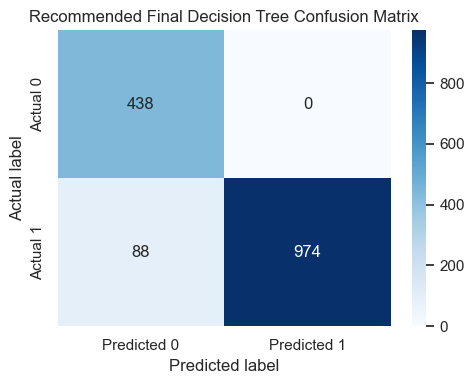

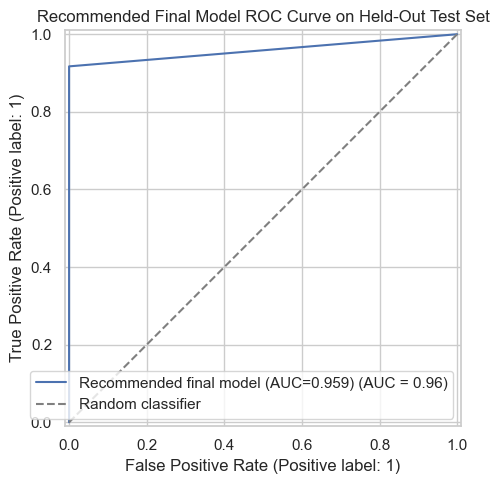

In [23]:
recommended_final_predictions = recommended_final_model.predict(recommended_final_X_test)
recommended_final_positive_scores = get_positive_class_scores(
    recommended_final_model,
    recommended_final_X_test
)

recommended_final_metrics = evaluate_classifier(
    'Recommended final tuned decision tree',
    recommended_final_model,
    recommended_final_X_test,
    recommended_final_y_test
)

print('Recommended final model metrics on the held-out test set:')
display(pd.DataFrame([recommended_final_metrics]).round(4))

print('Classification report for recommended final model:')
print(classification_report(recommended_final_y_test, recommended_final_predictions, zero_division=0))

recommended_final_confusion_matrix = confusion_matrix(recommended_final_y_test, recommended_final_predictions)
plt.figure(figsize=(5, 4))
sns.heatmap(
    recommended_final_confusion_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)
plt.title('Recommended Final Decision Tree Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    recommended_final_y_test,
    recommended_final_positive_scores,
    name=f'Recommended final model (AUC={recommended_final_metrics["roc_auc"]:.3f})',
    ax=ax
)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
ax.set_title('Recommended Final Model ROC Curve on Held-Out Test Set')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


### Recommended Final Decision Tree Structure

The recommended final decision tree can be visualized directly because tuning keeps it shallow enough to inspect. This plot shows the split rules, class counts, and predicted class at each node. It should be read as evidence that the model has learned simple threshold rules in this dataset, not as causal proof.


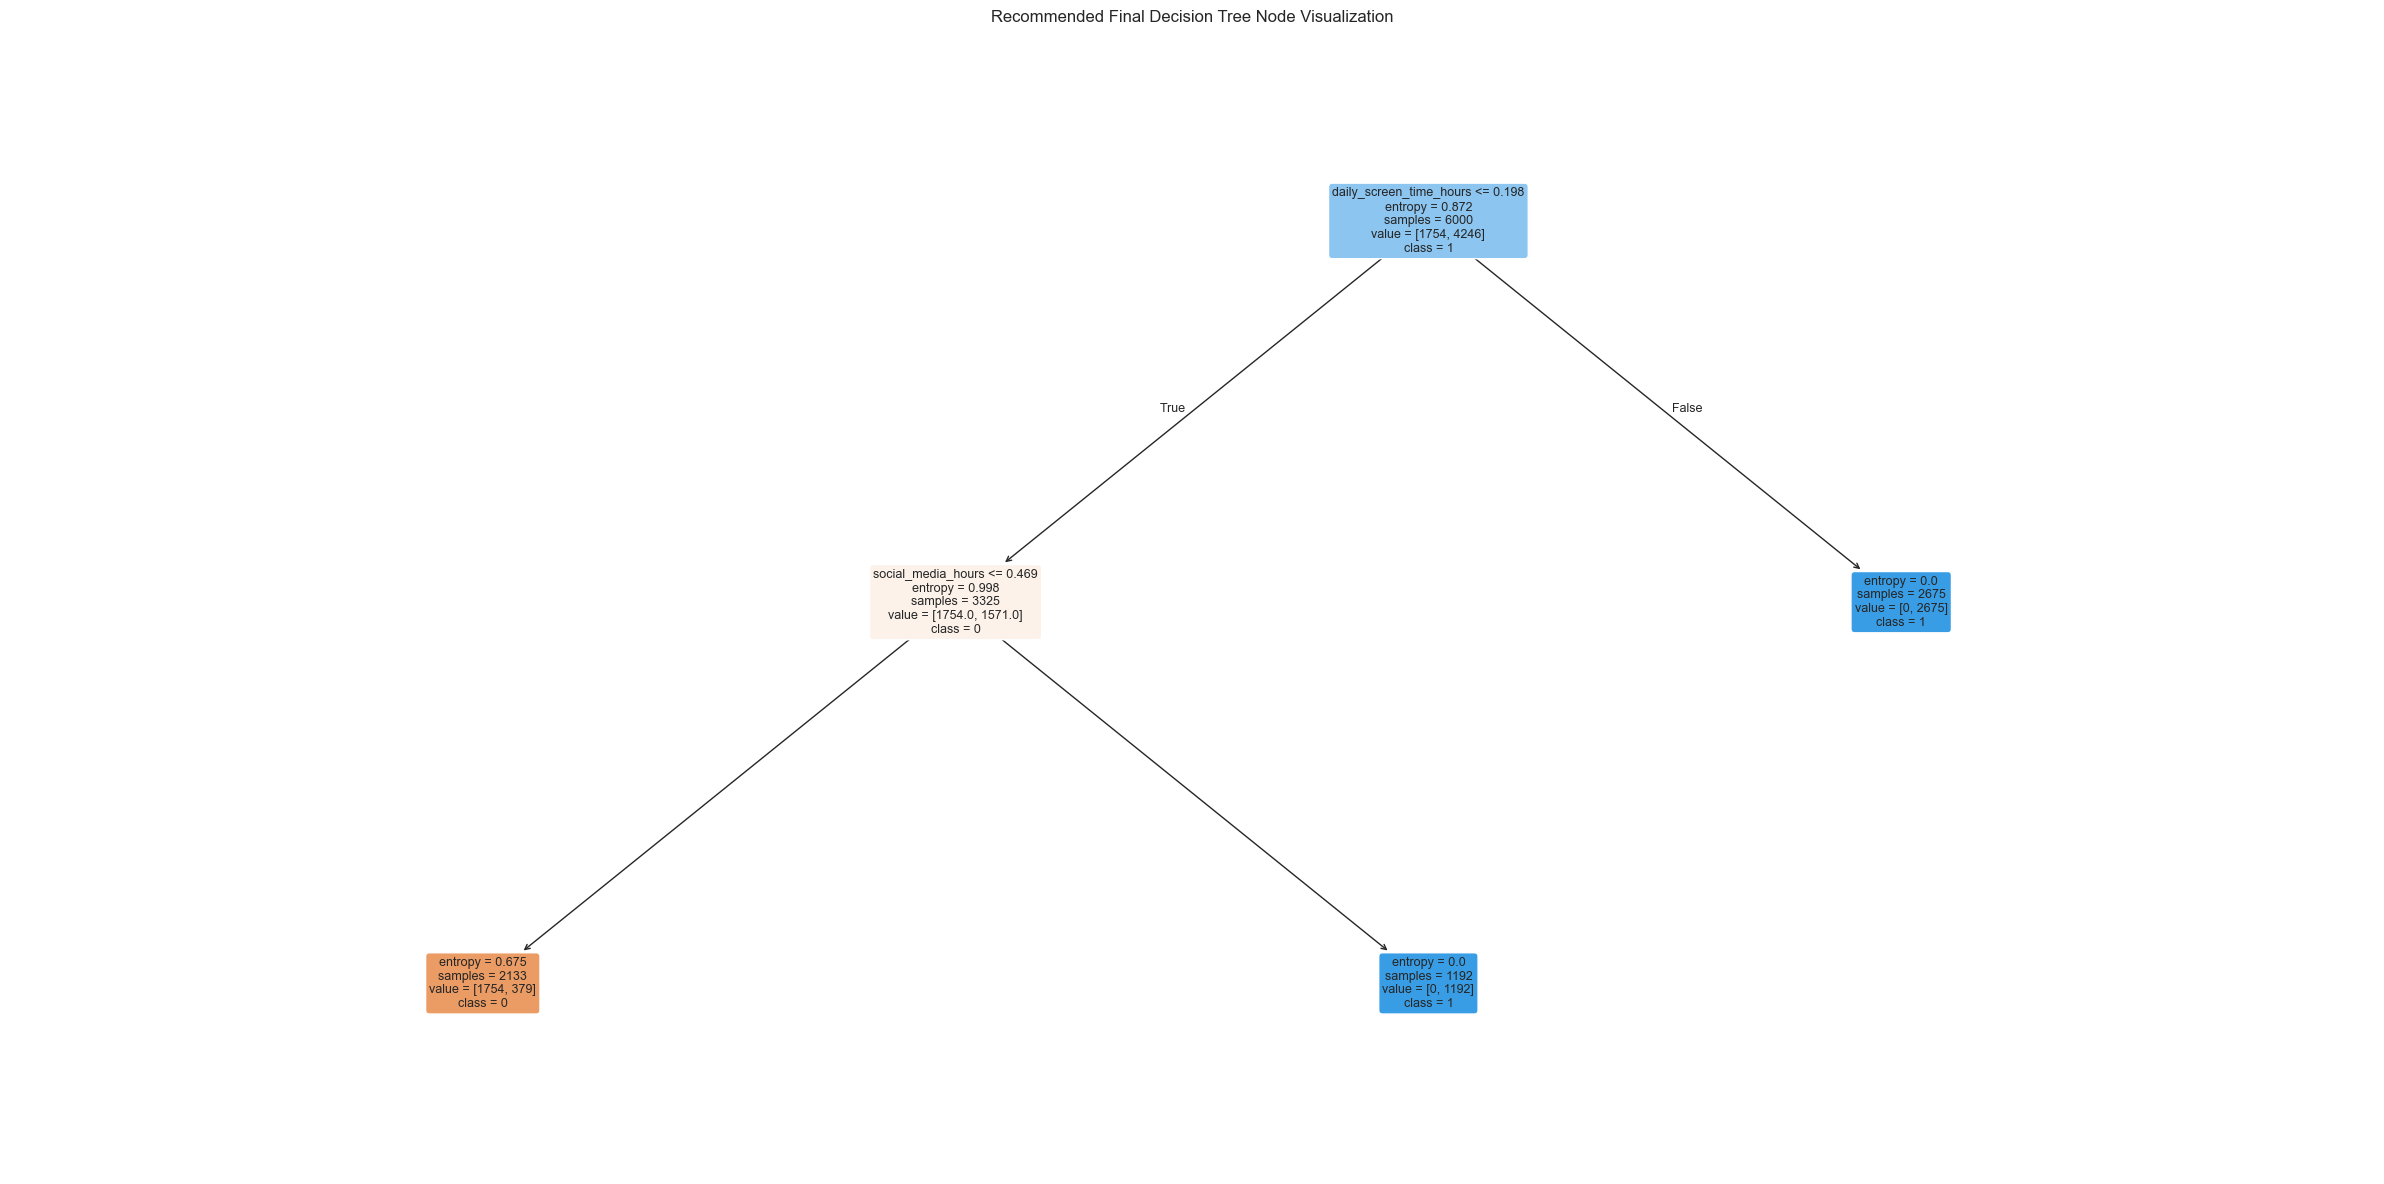

In [24]:
plt.figure(figsize=(24, 12))
plot_tree(
    recommended_final_model.named_steps['model'],
    feature_names=recommended_final_feature_names,
    class_names=['0', '1'],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    fontsize=9
)
plt.title('Recommended Final Decision Tree Node Visualization')
plt.tight_layout()
plt.show()


### Recommended Final Model Feature Importance

The decision tree's feature importance values help identify which variables contributed most to the selected model. These importances are model-specific, so they should be interpreted as predictive signals rather than causal effects.

Top 10 feature importances for the recommended final decision tree:


,feature,importance
0,daily_screen_time_hours,0.5046
1,social_media_hours,0.4954
2,age,0.0000
3,gaming_hours,0.0000
4,work_study_hours,0.0000
5,sleep_hours,0.0000
6,notifications_per_day,0.0000
7,app_opens_per_day,0.0000
8,weekend_screen_time,0.0000
9,sleep_below_7_hours,0.0000


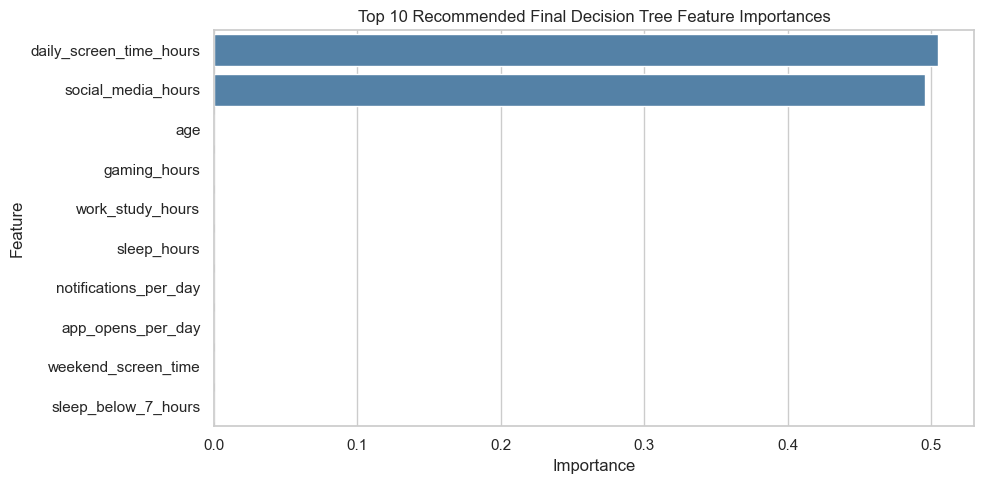

In [25]:
feature_importance_df = (
    pd.DataFrame({
        'feature': recommended_final_feature_names,
        'importance': recommended_final_model.named_steps['model'].feature_importances_
    })
    .sort_values(by='importance', ascending=False)
    .reset_index(drop=True)
)

print('Top 10 feature importances for the recommended final decision tree:')
display(feature_importance_df.head(10).round(4))

plt.figure(figsize=(10, 5))
sns.barplot(
    data=feature_importance_df.head(10),
    x='importance',
    y='feature',
    color='steelblue'
)
plt.title('Top 10 Recommended Final Decision Tree Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


### Permutation Feature Importance

Tree feature importance can favor variables that split the tree efficiently and is tied to the selected model form. Permutation importance measures the drop in held-out macro-F1 after shuffling each feature, so it provides a more direct check of which inputs the final model depends on for test-set performance.


Permutation importance on held-out test set, scored by macro-F1:


,feature,permutation_importance_mean,permutation_importance_std
0,daily_screen_time_hours,0.2957,0.0139
1,social_media_hours,0.2468,0.0099
2,age,0.0000,0.0000
3,gaming_hours,0.0000,0.0000
4,work_study_hours,0.0000,0.0000
5,sleep_hours,0.0000,0.0000
6,notifications_per_day,0.0000,0.0000
7,app_opens_per_day,0.0000,0.0000
8,weekend_screen_time,0.0000,0.0000
9,sleep_below_7_hours,0.0000,0.0000


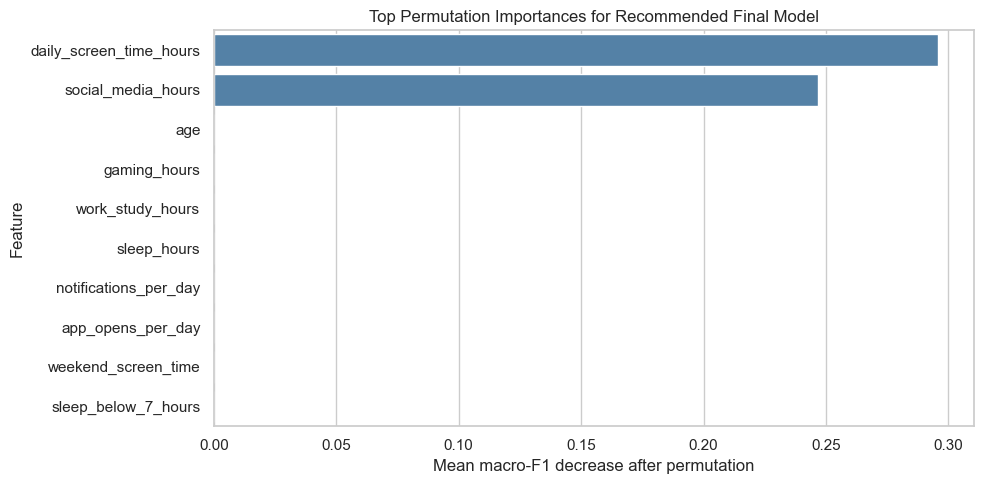

In [26]:
from sklearn.inspection import permutation_importance

permutation_result = permutation_importance(
    recommended_final_model,
    recommended_final_X_test,
    recommended_final_y_test,
    scoring='f1_macro',
    n_repeats=20,
    random_state=42,
    n_jobs=None
)

permutation_importance_df = (
    pd.DataFrame({
        'feature': recommended_final_feature_columns,
        'permutation_importance_mean': permutation_result.importances_mean,
        'permutation_importance_std': permutation_result.importances_std
    })
    .sort_values(by='permutation_importance_mean', ascending=False)
    .reset_index(drop=True)
)

print('Permutation importance on held-out test set, scored by macro-F1:')
display(permutation_importance_df.round(4))

plt.figure(figsize=(10, 5))
sns.barplot(
    data=permutation_importance_df.head(10),
    x='permutation_importance_mean',
    y='feature',
    color='steelblue'
)
plt.title('Top Permutation Importances for Recommended Final Model')
plt.xlabel('Mean macro-F1 decrease after permutation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


### Repeated Cross-Validation Stability Check

The primary split uses `random_state=42`, but a single split can be lucky or unlucky. Repeated stratified cross-validation checks whether the selected final decision-tree setup remains stable across multiple fold partitions. This is a robustness diagnostic, not a replacement for the held-out final test report.


In [27]:
repeated_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
recommended_tree_params = recommended_final_model.named_steps['model'].get_params()
stability_pipeline = build_model_pipeline(
    DecisionTreeClassifier(**recommended_tree_params),
    recommended_final_feature_columns
)

stability_scores = cross_validate(
    stability_pipeline,
    df_prepared[recommended_final_feature_columns],
    y,
    cv=repeated_cv,
    scoring=cv_scoring,
    n_jobs=None
)

stability_summary = pd.DataFrame([
    {
        'metric': 'macro_f1',
        'mean': stability_scores['test_macro_f1'].mean(),
        'std': stability_scores['test_macro_f1'].std()
    },
    {
        'metric': 'balanced_accuracy',
        'mean': stability_scores['test_balanced_accuracy'].mean(),
        'std': stability_scores['test_balanced_accuracy'].std()
    },
    {
        'metric': 'roc_auc',
        'mean': stability_scores['test_roc_auc'].mean(),
        'std': stability_scores['test_roc_auc'].std()
    },
    {
        'metric': 'recall_0',
        'mean': stability_scores['test_recall_0'].mean(),
        'std': stability_scores['test_recall_0'].std()
    },
    {
        'metric': 'recall_1',
        'mean': stability_scores['test_recall_1'].mean(),
        'std': stability_scores['test_recall_1'].std()
    }
])

print('Repeated stratified cross-validation stability summary for the final model setup:')
display(stability_summary.round(4))


Repeated stratified cross-validation stability summary for the final model setup:


,metric,mean,std
0,macro_f1,0.9288,0.0048
1,balanced_accuracy,0.9558,0.0031
2,roc_auc,0.9558,0.0031
3,recall_0,0.9995,0.0009
4,recall_1,0.9121,0.0063


### Logistic Regression Coefficient Interpretation

A standardized logistic regression is fit on the final feature set as an interpretable companion model. The coefficients describe direction and relative magnitude after the same preprocessing pipeline, but they are still associative and may reflect the synthetic label rules rather than real-world behavioral effects.


Top standardized logistic regression coefficients by absolute magnitude:


,feature,standardized_logistic_coefficient,abs_coefficient,direction
0,daily_screen_time_hours,2.6201,2.6201,higher predicted probability of label 1
1,social_media_hours,2.2681,2.2681,higher predicted probability of label 1
2,sleep_displacement_ratio,0.6365,0.6365,higher predicted probability of label 1
3,sleep_hours,0.3483,0.3483,higher predicted probability of label 1
4,stress_level_Medium,0.1943,0.1943,higher predicted probability of label 1
5,stress_level_Low,0.1621,0.1621,higher predicted probability of label 1
6,weekend_screen_time,-0.0963,0.0963,lower predicted probability of label 1
7,gaming_hours,0.0552,0.0552,higher predicted probability of label 1
8,age,0.0508,0.0508,higher predicted probability of label 1
9,app_opens_per_day,-0.0432,0.0432,lower predicted probability of label 1


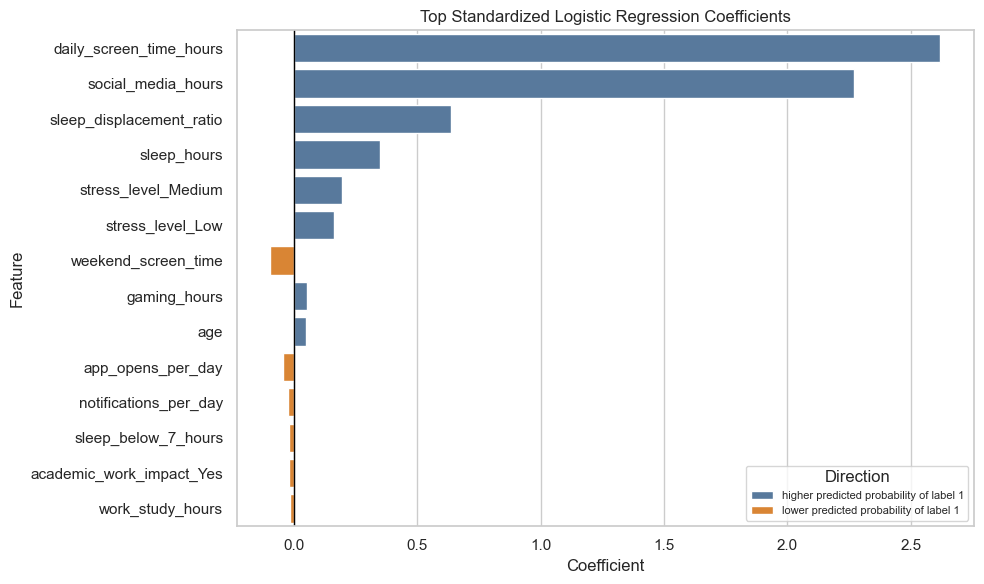

In [28]:
logistic_interpretation_pipeline = build_model_pipeline(
    LogisticRegression(max_iter=1000, random_state=42),
    recommended_final_feature_columns
)
logistic_interpretation_pipeline.fit(recommended_final_X_train, recommended_final_y_train)

logistic_feature_names = [
    name.replace('num__', '').replace('cat__', '')
    for name in logistic_interpretation_pipeline.named_steps['preprocess'].get_feature_names_out()
]

logistic_coefficient_df = (
    pd.DataFrame({
        'feature': logistic_feature_names,
        'standardized_logistic_coefficient': logistic_interpretation_pipeline.named_steps['model'].coef_[0]
    })
    .assign(abs_coefficient=lambda frame: frame['standardized_logistic_coefficient'].abs())
    .sort_values(by='abs_coefficient', ascending=False)
    .reset_index(drop=True)
)
logistic_coefficient_df['direction'] = np.where(
    logistic_coefficient_df['standardized_logistic_coefficient'] >= 0,
    'higher predicted probability of label 1',
    'lower predicted probability of label 1'
)

print('Top standardized logistic regression coefficients by absolute magnitude:')
display(logistic_coefficient_df.head(15).round(4))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=logistic_coefficient_df.head(15),
    x='standardized_logistic_coefficient',
    y='feature',
    hue='direction',
    dodge=False,
    palette=['#4C78A8', '#F58518']
)
plt.axvline(0, color='black', linewidth=1)
plt.title('Top Standardized Logistic Regression Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.legend(title='Direction', fontsize=8)
plt.tight_layout()
plt.show()


### Synthetic Rule and Zero False-Positive Check

The final model has zero false positives on the held-out test set, which is unusual for real behavioral data. The following diagnostic checks whether simple threshold rules explain most positive labels and whether an unrestricted tree can memorize the non-leaking feature space. These checks do not change the selected model; they clarify that the dataset behaves like a synthetic rule-generated classroom dataset.


In [29]:
simple_positive_rule = (
    (df_prepared['daily_screen_time_hours'] > 8.0)
    | (df_prepared['social_media_hours'] > 4.0)
)

rule_crosstab = pd.crosstab(
    simple_positive_rule.rename('daily_screen_time_gt_8_or_social_media_gt_4'),
    df_prepared['addicted_label']
)

print('Simple threshold rule vs addicted_label:')
display(rule_crosstab)

positive_cases_captured = (
    simple_positive_rule & (df_prepared['addicted_label'] == 1)
).sum()
total_positive_cases = (df_prepared['addicted_label'] == 1).sum()

print(
    f"Simple rule captures {positive_cases_captured:,} of {total_positive_cases:,} "
    f"positive labels ({positive_cases_captured / total_positive_cases * 100:.2f}%)."
)
print(
    f"False positives from this simple rule: "
    f"{((simple_positive_rule) & (df_prepared['addicted_label'] == 0)).sum():,}"
)

unrestricted_tree_pipeline = build_model_pipeline(
    DecisionTreeClassifier(random_state=42),
    recommended_final_feature_columns
)
unrestricted_tree_pipeline.fit(
    df_prepared[recommended_final_feature_columns],
    y
)
unrestricted_training_accuracy = unrestricted_tree_pipeline.score(
    df_prepared[recommended_final_feature_columns],
    y
)

print(f'Unrestricted tree training accuracy on all prepared rows: {unrestricted_training_accuracy:.4f}')
print(
    'This is a training-set memorization diagnostic, not a generalization metric. '
    'It supports treating the labels as likely rule-generated rather than clinically observed.'
)


Simple threshold rule vs addicted_label:


addicted_label,0,1
daily_screen_time_gt_8_or_social_media_gt_4,,
False,2192,467
True,0,4841


Simple rule captures 4,841 of 5,308 positive labels (91.20%).
False positives from this simple rule: 0
Unrestricted tree training accuracy on all prepared rows: 1.0000
This is a training-set memorization diagnostic, not a generalization metric. It supports treating the labels as likely rule-generated rather than clinically observed.


### Person 4 Modeling Interpretation

1. Best model family: the decision tree was selected using training-only cross-validation because it had the strongest macro-F1 score and remains explainable.
2. Recommended final model: the tuned decision tree with the cleaner behavioral feature set is preferred because it matches the full engineered feature set in training-only CV macro-F1 while avoiding unreliable aggregate/intensity features.
3. Final model performance: the recommended final decision tree achieved about 94.13% accuracy, 100.00% precision for class `1`, 91.71% recall for class `1`, 95.86% balanced accuracy, 95.68% class-1 F1-score, and 93.27% macro-F1 on the held-out test set.
4. Baseline comparison: the recommended final decision tree clearly beats the majority-class baseline, which mainly benefits from predicting the majority class and has no true negatives.
5. Confusion matrix interpretation: the recommended final decision tree produced 438 true negatives, 974 true positives, 0 false positives, and 88 false negatives.
6. Important features: the recommended final tree relies most heavily on daily screen time and social-media hours; permutation importance is added as a held-out robustness check against built-in tree importance.
7. Additional diagnostics: ROC-AUC, repeated stratified cross-validation, and standardized logistic regression coefficients are included to check discrimination, split stability, and interpretable direction of association.
8. Synthetic-data caution: the zero false-positive result is explained by simple threshold behavior in the dataset. This suggests the model is learning simulated label rules, not real clinical diagnostic behavior.
9. Gender and addiction-level decision: gender showed weak association with the target and is excluded from modeling; `addiction_level` behaves as a target proxy and is also excluded.
9. Limitation: these results show prediction and association only. The model should not be interpreted as proving that any feature causes smartphone addiction, and it should not be used as a medical or clinical diagnosis tool.


### Person 4 Handoff to Final Summary

1. Best model name: recommended final tuned decision tree classifier using behavioral usage features, without gender, addiction level, or unreliable aggregate/intensity engineered features.
2. Key metrics: accuracy about 94.13%, precision about 100.00%, recall about 91.71%, balanced accuracy about 95.86%, class-1 F1-score about 95.68%, and macro-F1 about 93.27% on the held-out test set.
3. Main modeling conclusion: the non-leaking behavioral features can predict `addicted_label` much better than the majority-class baseline, especially using daily screen time and social-media hours.
4. Gender decision: gender was tested before modeling and showed weak relationship with `addicted_label`, so it was dropped from the model instead of imputing or removing the `Other` category.
5. Addiction-level decision: `addiction_level` was excluded from the model because it behaves like a target proxy. Including it would create leakage and make the model look unrealistically strong.
6. Engineered-feature decision: the model without unreliable aggregate/intensity engineered features matched the full feature set in training-only CV macro-F1 and is easier to explain, so it is recommended as the final model.
7. Added audit diagnostics: ROC-AUC curves, permutation importance, repeated stratified cross-validation, and logistic regression coefficients are included for more complete model evaluation and interpretation.
8. Synthetic-data caveat: the final model's zero false positives and simple threshold splits should be framed as evidence that the model learned the dataset's rule-like label structure, not real-world diagnostic truth.
9. Recommended final-summary wording: describe the strongest variables as "predictive of" or "associated with" the target, not as causes.


## 5. Final Summary and Limitations - All

This analysis used the smartphone usage dataset to examine patterns associated with `addicted_label` and to test whether the label can be predicted using non-leaking behavioral features. The final prepared analysis keeps all 7,500 rows, including the `Other` gender category, because gender is not used as a model feature and does not need to be imputed or removed for prediction.

Cleaning found no duplicate rows, no duplicate `transaction_id`, and no duplicate `user_id`. The source columns passed the column-level validity checks for required schema, ID patterns, numeric plausibility bounds, integer count fields, categorical allowed values, and binary target values. The only source-column missingness was in `addiction_level`, with 819 missing values. These missing values are shown as `Not recorded` for descriptive EDA only; they are not imputed as a real severity category and are not used in the predictive model.

Preprocessing retained valid behavioral variables, created simple engineered usage features for exploration, and excluded leakage or non-modeling columns from `X`: `transaction_id`, `user_id`, `addicted_label`, `addiction_level`, `addiction_level_display`, and `gender`. The gender diagnostic showed weak relationship with the target, so gender was dropped from modeling while all rows were retained. The addiction-level diagnostic showed that `Not recorded` and `Mild` align with label `0`, while `Moderate` and `Severe` align with label `1`; this confirms that `addiction_level` behaves as a target proxy and must be excluded.

The strongest descriptive differences were in screen-time-related variables. Users with `addicted_label = 1` had higher average daily screen time, weekend screen time, social media hours, and sleep displacement ratio than users with `addicted_label = 0`. Formal numeric hypothesis tests were added to support the descriptive comparison, while still treating the results as associative. Stress level, academic/work impact, gender, sleep hours, notifications, and app opens showed weaker descriptive separation.

Age subgroup analysis now checks usage patterns and addicted-label rates across ages 18-22, 23-27, and 28-35. An unsupervised K-means clustering section also profiles behavioral usage segments without using the target, then compares the resulting clusters back to `addicted_label` for interpretation.

The analysis also found important synthetic-data caveats. The age range is narrow, from 18 to 35, so results should not be generalized to children, teenagers, or older adults. Although individual column values pass validity checks, some rows violate basic time-budget logic when columns are combined, and component-hour fields often exceed total daily screen time. Therefore, aggregate/intensity features based on those components should not be overinterpreted. The local project files do not define whether `weekend_screen_time` is an average weekend-day value or a total weekend value, so the notebook treats it as an unverified predictive feature rather than making strong behavioral claims about weekend usage.

For predictive modeling, model-family selection used training-only cross-validation before held-out test reporting. Numeric imputation, scaling, and categorical encoding were moved inside sklearn pipelines so preprocessing is fit only on training folds. Macro-F1 was used as the main selection and tuning metric because the target is imbalanced and both classes matter, and ROC-AUC was added as a threshold-independent comparison metric. The decision tree remained the selected model because it performed strongly and is explainable. A training-only sensitivity check showed that removing unreliable aggregate/intensity engineered features matched the full feature set in cross-validation macro-F1 while making the model simpler, so the recommended final model is the tuned decision tree using the cleaner behavioral feature set.

The final modeling section now includes held-out ROC-AUC, permutation feature importance, repeated stratified cross-validation for stability, and standardized logistic regression coefficients as an interpretable companion model. These additions make the evaluation more complete, but they do not remove the central limitation that the labels appear rule-generated.

The recommended final decision tree outperformed the majority-class baseline and achieved about 94.13% accuracy, 100.00% precision for class `1`, 91.71% recall for class `1`, 95.86% balanced accuracy, 95.68% class-1 F1-score, and 93.27% macro-F1 on the held-out test set. The notebook includes the final confusion matrix, feature importance chart, and a node-level visualization of the recommended final decision tree.

The final confusion matrix has zero false positives, which would be unusual in real behavioral or clinical data. A diagnostic threshold check shows that much of the target can be explained by simple screen-time and social-media thresholds, and an unrestricted tree can memorize the prepared labels. This supports treating the model as a strong classroom predictor of a likely synthetic label, not as a validated real-world addiction detector.

Important limitations: the dataset is observational and likely synthetic, so findings are associated with or predictive of the target rather than causal. The model should not be used as a medical or clinical diagnosis tool. `weekend_screen_time` needs careful interpretation because its exact measurement basis is not fully validated. `addiction_level` appears to define or closely proxy the target, so it is useful only for descriptive checking and not for prediction. Gender is retained for descriptive completeness but excluded from modeling, so the model should not be interpreted as using gender for prediction. Feature importance values are model-specific and should not be interpreted as universal causal importance.

Future improvements could validate the dataset source, confirm the meaning of `weekend_screen_time`, test additional train/test splits or repeated cross-validation, use permutation importance for more robust feature interpretation, and compare simpler models if explainability is more important than small performance differences.
